## 0. Imports

In [1]:
import json
import os
import torch
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

import scgen

from src.model.VAE.VAE_model import MixturePriorSCVI, SCVIMixturePriorWrapper, assign_cluster_idx
from src.model.SCGEN.SCGEN_model import SCGENMixturePriorWrapper
from src.model.Mean.Mean_model import MeanShifter
from src.model.data_utils import (
    load_data,
    get_condition_vocab,
    split_holdout_combinations,
    load_metacells,
    copy_with_log_transform,
)

from src.analysis.analysis_utils import Analyzer, get_model_from_checkpoint
from src.model.naming import resolve_checkpoint, holdout_suffix
from src.analysis.logistic_regression import (
    generate_counterfactuals,
    generate_counterfactuals_scvi,
    generate_counterfactuals_scgen,
    generate_counterfactuals_mean,
    evaluate_cf_roc,
)
from src.analysis.mmd import (
    ctrl_mmd_dists,
    mmd_dists,
    plot_mmd_dists,
    global_mmd_by_key,
    plot_global_mmd_boxplot,
)
from src.analysis.cf_expressions import (
    plot_mean_expression_comparison,
    plot_effect_size_comparison,
    plot_top_deg_violin,
)
from src.analysis.INN_OOD import (
    sample_leftout_combo_normal as inn_sample_leftout_combo_normal,
    sample_leftout_combo_shift as inn_sample_leftout_combo_shift,
    scoped_analyzer_for_combo,
    cfs_fn_from_adata,
    evaluate_leftout_combo_mmd,
    observed_combos_from_adata,
)
from src.analysis.Mean_OOD import (
    sample_leftout_combo_normal as mean_sample_leftout_combo_normal,
    sample_leftout_combo_shift as mean_sample_leftout_combo_shift,
)

## 1. Config

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
key = "CT-1"

## 2. Load Models

In [3]:
comparison_dir = "/home/jhoefer/sandbox/results/comparison"

USE_METACELLS = True

combo_conditions = ["cytokine", "cell_type"]
# The same named combos every training path holds out (train.py --holdout_file,
# scgen.ipynb, scvi.ipynb), so all four models here are compared on identical data and on
# the same ten OOD combos. Ten rather than one is what gives the OOD metrics an error bar.
# Set HOLDOUT_FILE = None to fall back to the single combo below.
HOLDOUT_FILE = "/home/jhoefer/sandbox/configs/holdout_combos.json"
HOLDOUT_COMBO = {"cytokine": "IL-2", "cell_type": "CD8 Memory"}  # only if HOLDOUT_FILE is None

if HOLDOUT_FILE is not None:
    with open(HOLDOUT_FILE) as handle:
        HOLDOUT_COMBOS = json.load(handle)
    # sections 4.x evaluate one combo at a time; take it from the set rather than leaving
    # the hardcoded value, so it is guaranteed to be one the models actually held out
    HOLDOUT_NAME, HOLDOUT_COMBO = next(iter(HOLDOUT_COMBOS.items()))
elif HOLDOUT_COMBO is not None:
    HOLDOUT_COMBOS, HOLDOUT_NAME = {"combo_1": HOLDOUT_COMBO}, "combo_1"
else:
    HOLDOUT_COMBOS, HOLDOUT_NAME = {}, None

# train.py's own path component ("_holdout_combos"), from the helper the training
# script and eoflow.ipynb both build it with, so the three cannot drift. The copy
# that used to live here replaced spaces but not slashes, so a single-combo holdout
# on "B Intermediate/Memory" would have opened a directory level instead of naming
# one, and it had no equivalent of --holdout_name.
HOLDOUT_PATH_SUFFIX = holdout_suffix(holdout_file=HOLDOUT_FILE, combo=HOLDOUT_COMBO)
# cvae/ and scgen/ name their directories without the leading underscore that
# EOFlow's path component carries, so both spellings are kept.
HOLDOUT_SUFFIX = HOLDOUT_PATH_SUFFIX.removeprefix("_") or None

# every model splits on this list, so none of them can be trained on a combo another one
# holds out - the whole comparison rests on the four sharing a training set
HOLDOUT_LIST = list(HOLDOUT_COMBOS.values())

# The 4.x sections evaluate one combo at a time (HOLDOUT_COMBO, the first of the set), so
# every title says which one - otherwise a figure from a ten-combo run is indistinguishable
# from one produced when only that combo was held out.
HOLDOUT_LABEL = " x ".join(str(HOLDOUT_COMBO[c]) for c in combo_conditions) if HOLDOUT_COMBO else "none"
HOLDOUT_CONTEXT = f"{HOLDOUT_LABEL} ({HOLDOUT_NAME} of {len(HOLDOUT_COMBOS)} held out)"

if HOLDOUT_COMBOS:
    assert USE_METACELLS, "Holding out combos requires USE_METACELLS=True."
    print(f"{len(HOLDOUT_COMBOS)} held-out combo(s): "
          + ", ".join(f"{k}={v['cytokine']} x {v['cell_type']}" for k, v in HOLDOUT_COMBOS.items()))

10 held-out combo(s): combo_1=IL-2 x CD8 Memory, combo_2=CD27L x NK, combo_3=CD40L x CD14 Mono, combo_4=CT-1 x cDC, combo_5=FGF-beta x CD4 Naive, combo_6=IFN-epsilon x MAIT, combo_7=IL-1-beta x CD16 Mono, combo_8=IL-13 x CD4 Memory, combo_9=IL-32-beta x CD14 Mono, combo_10=IL-4 x NK


In [4]:
# All four sections below (2.1-2.4) load the same underlying data - same dataset,
# top_genes, and cell filtering/donors (and, when USE_METACELLS, group_keys) - just
# at different log_transform. Load the shared raw-count base once here and let each
# section take a cheap copy_with_log_transform() of it, instead of separately
# reloading four times: load_metacells's own on-disk cache already avoids re-running
# SEACells, but still re-reads that cache file from disk each time; load_data with
# USE_METACELLS=False has no caching at all and would otherwise reprocess the
# multi-GB source h5ad from scratch four times.
metacell_dataset_name = "parse"
metacell_top_genes = 2000
metacell_donors = ["Donor1"]
metacell_group_keys = ["cytokine", "cell_type"]

if USE_METACELLS:
    base_adata, base_labels_key, base_control_label = load_metacells(
        metacell_dataset_name,
        metacell_top_genes,
        metacell_group_keys,
        donors=metacell_donors,
        log_transform=False,
    )
else:
    base_adata, base_labels_key, base_control_label = load_data(
        metacell_dataset_name,
        metacell_top_genes,
        log_transform=False,
        cell_types=["CD4 Memory"],
    )

### 2.1 EOFlow

In [5]:
eoflow_dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 0.5,
    "lam_MTC": 0.6,
    "use_counts": False,
    "factorized_means": True,
    # mu = a_ct + w_ct * b_cy instead of a + b (train.sh GAIN=1, train.py
    # --treatment_gain). Its own directory, because the gain scalar makes the
    # checkpoint structurally different - remap_keys refuses to load one into the
    # other, so a shared path would be a failed load rather than a bad label.
    "treatment_gain": True,
    # part of the checkpoint name since train.py started recording them, so they have
    # to match the run being loaded. Legacy checkpoints predate the tokens and are
    # found regardless - resolve_checkpoint tries the old spelling as a fallback.
    "lr_means": 5e-4,
    "latent_per_condition": 2,
    "means_dim": None,
}


eoflow_prefix = "5e-4_" 
eoflow_postfix = "" #"_best_ood"

eoflow_adata = copy_with_log_transform(base_adata, log_transform=True)
eoflow_labels_key, eoflow_control_label = base_labels_key, base_control_label

eoflow_dataset_name = eoflow_dataset_args["dataset_name"]
eoflow_top_genes = min(eoflow_dataset_args["top_genes"], eoflow_adata.shape[1])
eoflow_sigma_noise = eoflow_dataset_args["sigma_noise"]
eoflow_lam_MTC = eoflow_dataset_args["lam_MTC"]

eoflow_model_path = os.path.join(
    "/g/stegle/jhoefer/models/EOFlow",
    eoflow_dataset_name,
    "top_" + str(eoflow_top_genes),
)
# the knobs the filename is built from. Spelling them here rather than concatenating
# the name by hand is the point: train.py builds it from the same function, so the two
# cannot drift the way the hand-typed `5e-3` prefixes did.
eoflow_name_knobs = dict(
    lam_MTC=eoflow_lam_MTC,
    sigma_noise=eoflow_sigma_noise,
    lr_means=eoflow_dataset_args["lr_means"],
    latent_per_condition=eoflow_dataset_args["latent_per_condition"],
    means_dim=eoflow_dataset_args["means_dim"],
)

if eoflow_dataset_args["use_counts"]:
    eoflow_model_path += "_counts"

if HOLDOUT_COMBO is None:
    eoflow_output_dir_path = os.path.join(
        "/home/jhoefer/sandbox/results",
        eoflow_dataset_name,
        "top_" + str(eoflow_top_genes),
    )
    eoflow_output_dir_name = (
        eoflow_prefix
        + "MTC_"
        + str(eoflow_lam_MTC)
        + "_sigma_"
        + str(eoflow_sigma_noise)
    )
    if eoflow_dataset_args["use_counts"]:
        eoflow_output_dir_path += "_counts"

    eoflow_model_path += "_best"
    eoflow_output_dir_path += "_best"

    eoflow_plot_dir = os.path.join(
        eoflow_output_dir_path, "plots", eoflow_output_dir_name
    )
    eoflow_csv_dir = os.path.join(eoflow_output_dir_path, "csv", eoflow_output_dir_name)
else:
    eoflow_model_path += "_metacells" + HOLDOUT_PATH_SUFFIX
    eoflow_model_path += "_factorized" if eoflow_dataset_args["factorized_means"] else ""
    # after _factorized, matching the order train.py appends them in
    eoflow_model_path += "_gain" if eoflow_dataset_args["treatment_gain"] else ""

    eoflow_plot_dir = os.path.join(comparison_dir, "ood_eoflow", "plots")
    eoflow_csv_dir = os.path.join(comparison_dir, "ood_eoflow", "csv")

# os.makedirs(eoflow_plot_dir, exist_ok=True)
# os.makedirs(eoflow_csv_dir, exist_ok=True)

# raises if neither spelling is present, rather than falling through to an untrained
# model; prefers the current spelling when both exist, so a fresh run is never masked
# by the legacy file sitting next to it.
eoflow_checkpoint_path = resolve_checkpoint(
    eoflow_model_path,
    prefix=eoflow_prefix,
    postfix=eoflow_postfix,
    **eoflow_name_knobs,
)
print(f"EOFlow checkpoint: {eoflow_checkpoint_path}")

eoflow_model, _, eoflow_metrics_loss, eoflow_val_metrics_loss, eoflow_model_config = (
    get_model_from_checkpoint(eoflow_checkpoint_path, device)
)

# Resolve what the checkpoint was actually trained on *before* building the Analyzer.
# A leave-combo-out model indexes its prior means by (cytokine, cell_type) combos, so an
# Analyzer told conditions=[labels_key] would index 198 combo means with 11 cytokine
# indices and read the wrong rows - silently, since both are valid indices.
if HOLDOUT_COMBO is not None:
    eoflow_combo_conditions = eoflow_model_config.conditions or [
        eoflow_labels_key,
        "cell_type",
    ]
    eoflow_combo_categories = eoflow_model_config.combo_categories
    eoflow_condition_categories = eoflow_model_config.condition_categories
    # taken from the checkpoint's own config rather than from HOLDOUT_LIST, so the split
    # always matches what this particular model was trained with. All of them are needed:
    # with a ten-combo holdout, [0] would leave the other nine in the training data and
    # they would then be scored as "OOD" while the model had in fact seen them.
    eoflow_holdout_combos = list(eoflow_model_config.holdout_combos)
    # the single combo the 4.1/4.2 registry and every 2x2 grid are built on. Taken from
    # HOLDOUT_COMBO, not from eoflow_holdout_combos[0]: the other three models get theirs
    # from HOLDOUT_COMBO, and if the checkpoint stored its combos in a different order the
    # EOFlow panel would show a different combo than the other three panels of the same
    # figure - with nothing in the output saying so.
    eoflow_holdout_combo = (
        HOLDOUT_COMBO if HOLDOUT_COMBO in eoflow_holdout_combos else eoflow_holdout_combos[0]
    )
    if eoflow_holdout_combo != HOLDOUT_COMBO:
        print(f"WARNING: {HOLDOUT_NAME} ({HOLDOUT_LABEL}) is not in the checkpoint's holdout "
              f"set; the EOFlow panels fall back to {eoflow_holdout_combo}.")
    eoflow_train_adata, _ = split_holdout_combinations(
        eoflow_adata, eoflow_holdout_combos, group_keys=eoflow_combo_conditions
    )

    # ...and check it against what the other models are holding out. A checkpoint trained
    # on a different holdout set is the one mismatch that would invalidate every
    # cross-model number here while looking perfectly normal in the outputs.
    _ckpt = {tuple(sorted(c.items())) for c in eoflow_holdout_combos}
    _shared = {tuple(sorted(c.items())) for c in HOLDOUT_LIST}
    if _ckpt != _shared:
        print(
            f"WARNING: the EOFlow checkpoint was trained holding out {len(_ckpt)} combo(s), "
            f"but this notebook holds out {len(_shared)}.\n"
            f"  only in checkpoint: {sorted(dict(c) for c in _ckpt - _shared)}\n"
            f"  only in notebook:   {sorted(dict(c) for c in _shared - _ckpt)}\n"
            "  Cross-model comparisons below are not valid until these agree."
        )
    # combos with actual training rows - `combo_categories` is the full Cartesian
    # product, so membership in it says nothing about whether a combo was ever fitted
    eoflow_observed_combos = observed_combos_from_adata(
        eoflow_train_adata, eoflow_combo_conditions
    )
    print(f"EOFlow: {len(HOLDOUT_LIST)} combo(s) held out of training; "
      f"sections 4.x evaluate {HOLDOUT_CONTEXT}")
    print(
        f"EOFlow observed combos: {len(eoflow_observed_combos)}/{len(eoflow_combo_categories)}"
    )
else:
    eoflow_combo_conditions = [eoflow_labels_key]
    eoflow_combo_categories = None
    eoflow_condition_categories = None
    eoflow_observed_combos = None

eoflow_analyzer = Analyzer(
    eoflow_adata,
    eoflow_model,
    {"device": device, "dtype": dtype, "sigma_noise": eoflow_sigma_noise},
    eoflow_labels_key,
    eoflow_control_label,
    eoflow_plot_dir,
    eoflow_csv_dir,
    checkpoint_path=eoflow_checkpoint_path,
    metrics_loss=eoflow_metrics_loss,
    conditions=eoflow_combo_conditions,
    condition_type=eoflow_model_config.condition_type,
    val_metrics_loss=eoflow_val_metrics_loss,
    combo_categories=eoflow_combo_categories,
    condition_categories=eoflow_condition_categories,
)

EOFlow checkpoint: /g/stegle/jhoefer/models/EOFlow/parse/top_1937_metacells_holdout_combos_factorized_gain/5e-4_MTC_0.6_sigma_0.5_lrm_0.0005_lpc_2_model.pt
Loaded successfully. Missing/fresh keys: []
Checkpoint found at epoch 2650.
EOFlow: 10 combo(s) held out of training; sections 4.x evaluate IL-2 x CD8 Memory (combo_1 of 10 held out)
EOFlow observed combos: 168/198


### 2.2 scVI

In [6]:
scvi_beta = 0.01
scvi_lr_means = 1e-5

scvi_adata = copy_with_log_transform(base_adata, log_transform=False)
scvi_labels_key, scvi_control_label = base_labels_key, base_control_label

if HOLDOUT_COMBO is None:
    scvi_adata.obs["cluster_idx"] = scvi_adata.obs[scvi_labels_key].astype("category").cat.codes
    scvi_train_adata = scvi_adata
    scvi_conditions = [scvi_labels_key]
    scvi_condition_categories = None
    scvi_combo_categories = None
    scvi_observed_combos = None
    scvi_model_path = "/g/stegle/jhoefer/models/cvae"
    scvi_plot_dir = os.path.join(comparison_dir, "scvi", "plots")
    scvi_csv_dir = os.path.join(comparison_dir, "scvi", "csv")
else:
    scvi_condition_categories, scvi_combo_categories = get_condition_vocab(
        scvi_adata, combo_conditions
    )
    # Assign on the FULL adata before splitting, so the training copy inherits it and the
    # analyzer's adata carries it too. scvi-tools validates any AnnData handed to
    # get_latent_representation() against the model's registry, which was set up with
    # cluster_key="cluster_idx" - and the analyzer below is built on scvi_adata, not on
    # scvi_train_adata, so assigning only to the latter left every counterfactual call
    # (section 3.1, 4.9) failing on a missing cluster_idx once a combo is held out.
    assign_cluster_idx(
        scvi_adata, conditions=combo_conditions, combo_categories=scvi_combo_categories
    )
    scvi_train_adata, _ = split_holdout_combinations(
        scvi_adata, HOLDOUT_LIST, group_keys=combo_conditions
    )
    # Re-assign after the split as well: subsetting an AnnData drops unused categories, so
    # the training copy would inherit 197 of the 198 components (the held-out combo has no
    # rows left) and every code past it would shift by one against the model's registry.
    # assign_cluster_idx sets the categories explicitly from combo_categories, restoring all 198.
    assign_cluster_idx(
        scvi_train_adata, conditions=combo_conditions, combo_categories=scvi_combo_categories
    )
    scvi_conditions = combo_conditions
    scvi_observed_combos = observed_combos_from_adata(scvi_train_adata, combo_conditions)

    scvi_model_path = f"/g/stegle/jhoefer/models/cvae/{HOLDOUT_SUFFIX}"
    scvi_plot_dir = os.path.join(comparison_dir, "ood_scvi", "plots")
    scvi_csv_dir = os.path.join(comparison_dir, "ood_scvi", "csv")

scvi_model = MixturePriorSCVI.load(
    scvi_model_path, adata=scvi_train_adata, prefix=f"{scvi_beta}_beta_{scvi_lr_means}_lr_means_"
)
scvi_wrapper = SCVIMixturePriorWrapper(scvi_model).to(device)

# os.makedirs(scvi_plot_dir, exist_ok=True)
# os.makedirs(scvi_csv_dir, exist_ok=True)

scvi_analyzer = Analyzer(
    scvi_adata,
    scvi_wrapper,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    scvi_labels_key,
    scvi_control_label,
    scvi_plot_dir,
    scvi_csv_dir,
    checkpoint_path=scvi_model_path,
    conditions=scvi_conditions,
    condition_type="mixture",
    combo_categories=scvi_combo_categories,
    condition_categories=scvi_condition_categories,
)

if HOLDOUT_COMBO is not None:
    scvi_holdout_combo = HOLDOUT_COMBO
    print(f"scVI: {len(HOLDOUT_LIST)} combo(s) held out of training; "
      f"sections 4.x evaluate {HOLDOUT_CONTEXT}")

INFO     File /g/stegle/jhoefer/models/cvae/holdout_combos/0.01_beta_1e-05_lr_means_model.pt already downloaded    
scVI: 10 combo(s) held out of training; sections 4.x evaluate IL-2 x CD8 Memory (combo_1 of 10 held out)


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


### 2.3 scGen

In [7]:
# log_transform=True: scGen's VAE is an MSE autoencoder over adata.X
# (SCGENVAE.get_reconstruction_loss is ((x - px)**2).sum(-1), decoder output is a bare
# nn.Linear, and sampling is Normal(px, 1)) - so it expects log-normalized expression,
# not counts, and registers X with is_count_data=False for exactly that reason. Only
# scVI above needs raw counts, for its NB/ZINB likelihood.
scgen_adata = copy_with_log_transform(base_adata, log_transform=True)
scgen_labels_key, scgen_control_label = base_labels_key, base_control_label

if HOLDOUT_COMBO is None:
    scgen_train_adata = scgen_adata
    scgen_conditions = [scgen_labels_key]
    scgen_combo_categories = None
    scgen_condition_categories = None
    scgen_model_path = "/g/stegle/jhoefer/models/scgen"
    scgen_plot_dir = os.path.join(comparison_dir, "scgen", "plots")
    scgen_csv_dir = os.path.join(comparison_dir, "scgen", "csv")
else:
    scgen_adata.obs["cluster_idx"] = scgen_adata.obs[scgen_labels_key].astype("category").cat.codes
    scgen_condition_categories, scgen_combo_categories = get_condition_vocab(
        scgen_adata, combo_conditions
    )
    scgen_train_adata, _ = split_holdout_combinations(
        scgen_adata, HOLDOUT_LIST, group_keys=combo_conditions
    )
    scgen_conditions = combo_conditions

    scgen_model_path = f"/g/stegle/jhoefer/models/scgen/{HOLDOUT_SUFFIX}"
    scgen_plot_dir = os.path.join(comparison_dir, "ood_scgen", "plots")
    scgen_csv_dir = os.path.join(comparison_dir, "ood_scgen", "csv")

scgen_model = scgen.SCGEN.load(os.path.join(scgen_model_path, "model.pt"), adata=scgen_train_adata)
scgen_wrapper = SCGENMixturePriorWrapper(
    scgen_model,
    scgen_train_adata,
    scgen_labels_key,
    conditions=scgen_conditions,
    combo_categories=scgen_combo_categories,
)

# os.makedirs(scgen_plot_dir, exist_ok=True)
# os.makedirs(scgen_csv_dir, exist_ok=True)

scgen_analyzer = Analyzer(
    scgen_adata,
    scgen_wrapper,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    scgen_labels_key,
    scgen_control_label,
    scgen_plot_dir,
    scgen_csv_dir,
    checkpoint_path=None,
    conditions=scgen_conditions,
    condition_type=None,
    combo_categories=scgen_combo_categories,
    condition_categories=scgen_condition_categories,
)

if HOLDOUT_COMBO is not None:
    scgen_holdout_combo = HOLDOUT_COMBO
    print(f"scGen: {len(HOLDOUT_LIST)} combo(s) held out of training; "
      f"sections 4.x evaluate {HOLDOUT_CONTEXT}")

INFO     File /g/stegle/jhoefer/models/scgen/holdout_combos/model.pt/model.pt already downloaded                   


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...


scGen: 10 combo(s) held out of training; sections 4.x evaluate IL-2 x CD8 Memory (combo_1 of 10 held out)


### 2.4 Means

In [8]:
mean_adata = copy_with_log_transform(base_adata, log_transform=True)
mean_labels_key, mean_control_label = base_labels_key, base_control_label

if HOLDOUT_COMBO is None:
    mean_train_adata = mean_adata
    mean_conditions = None
    mean_plot_dir = os.path.join(comparison_dir, "mean", "plots")
    mean_csv_dir = os.path.join(comparison_dir, "mean", "csv")
else:
    mean_train_adata, _ = split_holdout_combinations(
        mean_adata, HOLDOUT_LIST, group_keys=combo_conditions
    )
    mean_conditions = combo_conditions
    mean_plot_dir = os.path.join(comparison_dir, "ood_mean", "plots")
    mean_csv_dir = os.path.join(comparison_dir, "ood_mean", "csv")

MeanShifter.setup_anndata(mean_train_adata, mean_labels_key, mean_control_label)
mean_shifter = MeanShifter(mean_train_adata)
mean_shifter.train()

# os.makedirs(mean_plot_dir, exist_ok=True)
# os.makedirs(mean_csv_dir, exist_ok=True)

mean_analyzer = Analyzer(
    mean_adata,
    mean_shifter,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    mean_labels_key,
    mean_control_label,
    mean_plot_dir,
    mean_csv_dir,
    checkpoint_path=None,
    conditions=mean_conditions,
)

if HOLDOUT_COMBO is not None:
    mean_holdout_combo = HOLDOUT_COMBO
    print(f"Means: {len(HOLDOUT_LIST)} combo(s) held out of training; "
      f"sections 4.x evaluate {HOLDOUT_CONTEXT}")

Means: 10 combo(s) held out of training; sections 4.x evaluate IL-2 x CD8 Memory (combo_1 of 10 held out)


### 2.5 Registry

In [9]:
comparison_dir = "/home/jhoefer/sandbox/results/comparison"
comparison_dir = os.path.join(
    comparison_dir,
    eoflow_prefix
    + "MTC_"
    + str(eoflow_lam_MTC)
    + "_sigma_"
    + str(eoflow_sigma_noise),
)
comparison_dir += "_factorized" if eoflow_dataset_args["factorized_means"] else ""
comparison_dir += "_gain" if eoflow_dataset_args["treatment_gain"] else ""
plot_dir = os.path.join(comparison_dir, "plots")
os.makedirs(plot_dir, exist_ok=True)

models = [
    {
        "name": "EOFlow",
        "analyzer": eoflow_analyzer,
        "cf_fn": generate_counterfactuals,
        "log1p_transform": False,
    },
    {
        "name": "scVI",
        "analyzer": scvi_analyzer,
        "cf_fn": generate_counterfactuals_scvi,
        "log1p_transform": False,
    },
    {
        "name": "scGen",
        "analyzer": scgen_analyzer,
        "cf_fn": generate_counterfactuals_scgen,
        "log1p_transform": False,
    },
    {
        "name": "Means",
        "analyzer": mean_analyzer,
        "cf_fn": generate_counterfactuals_mean,
        "log1p_transform": False,
    },
]

## 3. Comparison Plots

### 3.1 ROC Curves

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for m, ax in zip(models, axes.flat):
    _, _, roc_auc = evaluate_cf_roc(m["analyzer"], key=key, cf_fn=m["cf_fn"], num_epochs=10, ax=ax)
    ax.set_title(f"{m['name']} (AUC = {roc_auc:.3f})")
fig.suptitle(f"ROC curves - counterfactuals vs original ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"roc_comparison_{key}.png"), dpi=300)
plt.show()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  6.74it/s]

Best Validation Accuracy: 0.9432
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             



/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 62 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 80 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 98 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 134 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make

...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


: 

: 

: 

### 3.2 MMD

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 23.69it/s]


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 62 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 80 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 98 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_c

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 134 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 175 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 116 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 152 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _m

...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 23.63it/s]


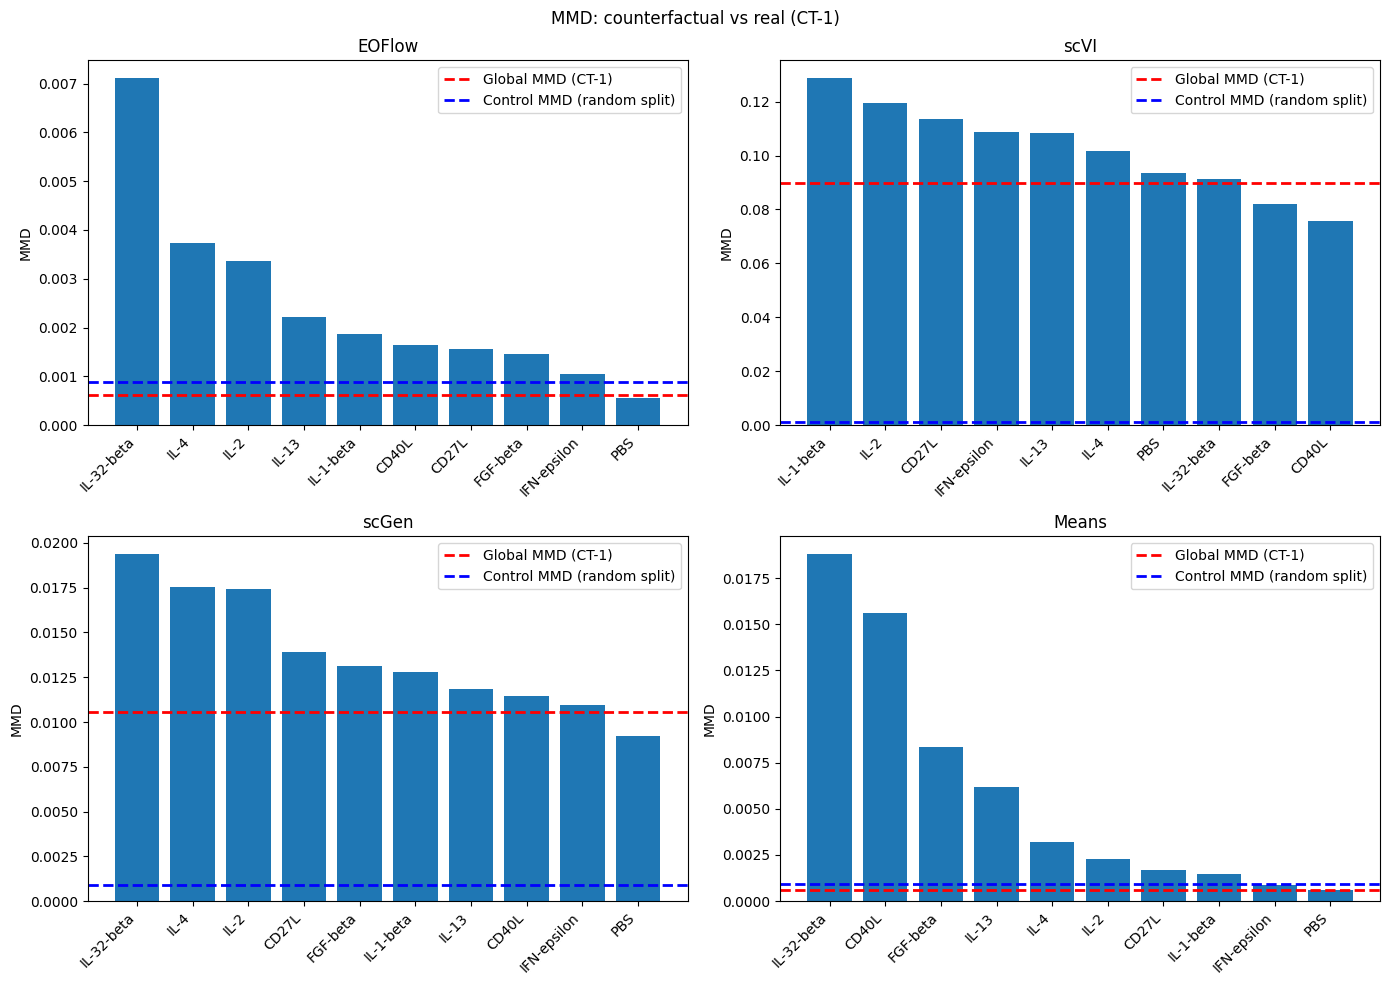

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    analyzer = m["analyzer"]
    ctrl_mmd = ctrl_mmd_dists(analyzer, key=key, log1p_transform=m["log1p_transform"])
    global_mmd, mmd_per_group = mmd_dists(
        analyzer, key=key, sigma=1.0, cf_fn=m["cf_fn"], log1p_transform=m["log1p_transform"]
    )
    plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key, ax=ax)
    ax.set_title(m["name"])
fig.suptitle(f"MMD: counterfactual vs real ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"mmd_comparison_{key}.png"), dpi=300)
plt.show()

### 3.2b Global MMD Across All Held-Out Keys

Repeats the global-MMD computation from 3.2 for every held-out cytokine key (not just `key`), for each method, and summarizes the resulting distributions as a box plot.

In [ ]:
global_mmd_all_keys = global_mmd_by_key(models)

plot_global_mmd_boxplot(global_mmd_all_keys, plot_dir=plot_dir)

scVI:   0%|                                                                                                                  | 0/10 [00:00<?, ?it/s]

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 45 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 62 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 80 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 98 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 116 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 175 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 116 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 152 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


: 

: 

### 3.3 Mean Expression

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 62 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 80 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 98 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_c

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 152 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


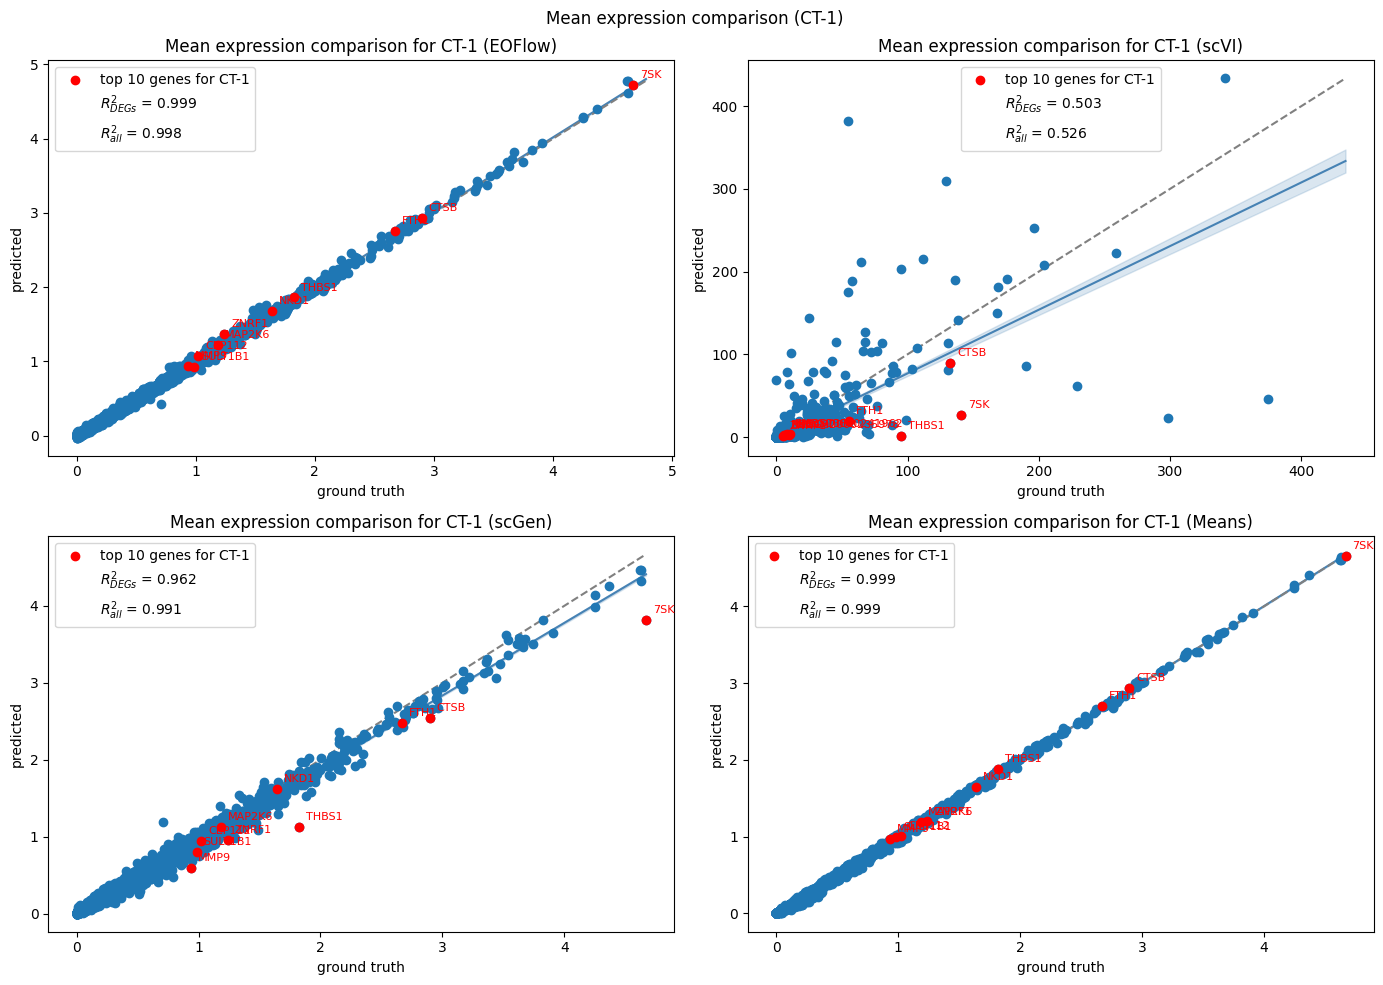

: 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    plot_mean_expression_comparison(
        m["analyzer"],
        key=key,
        top_n=10,
        cfs_fn=m["cf_fn"],
        log1p_transform=m["log1p_transform"],
        method=m["name"],
        ax=ax,
    )
fig.suptitle(f"Mean expression comparison ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"mean_expression_comparison_{key}.png"), dpi=300)
plt.show()

### 3.4 Effect Size

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 62 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 80 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 98 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 134 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 175 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 116 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _ma

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


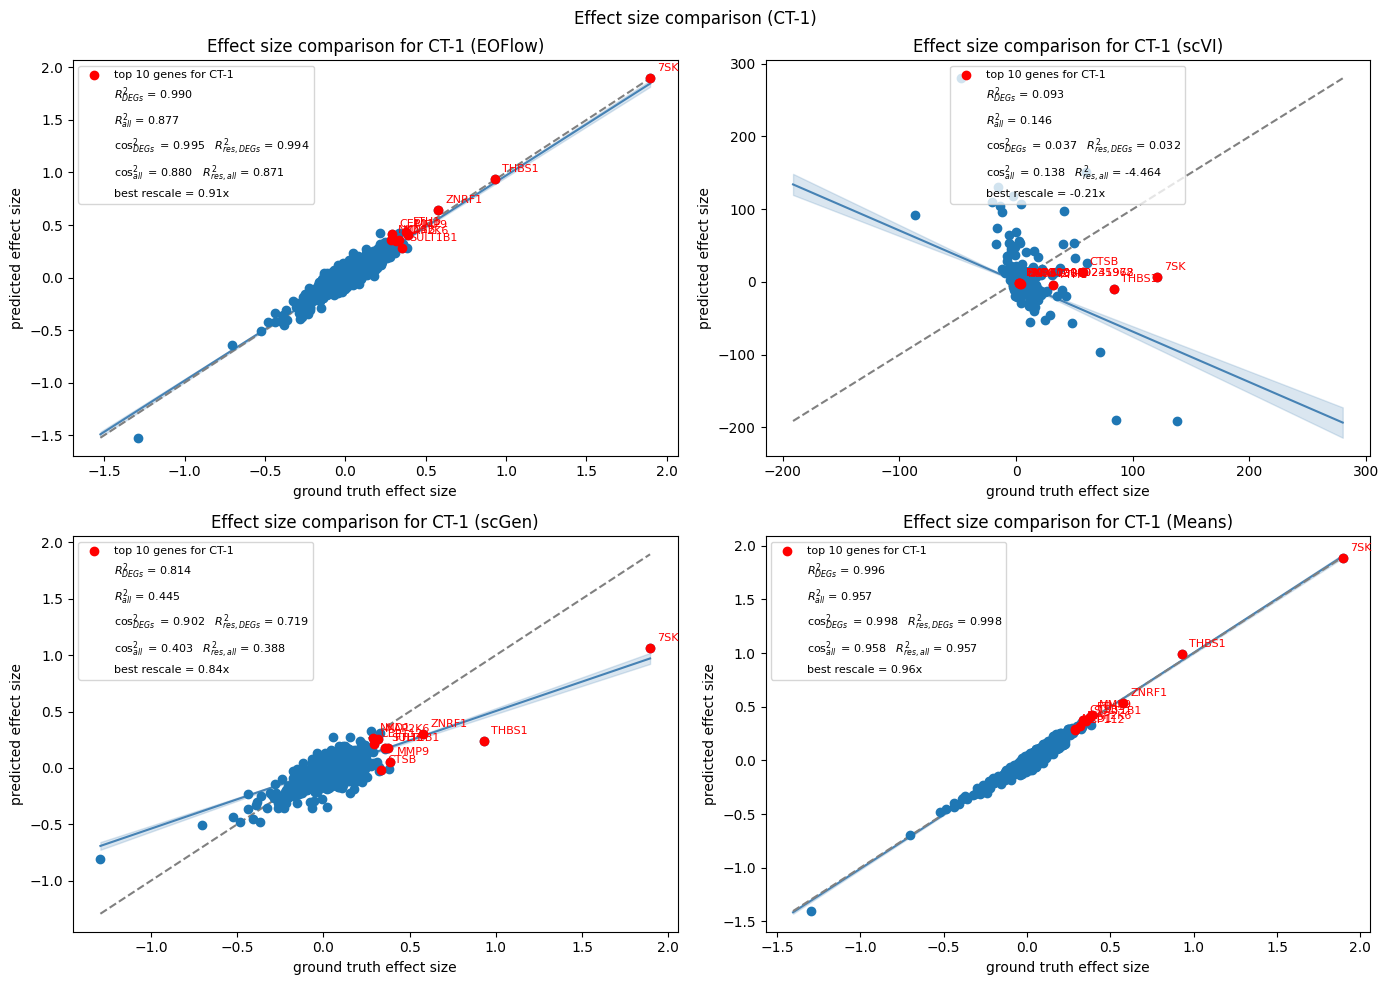

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    plot_effect_size_comparison(
        m["analyzer"],
        key=key,
        top_n=10,
        cfs_fn=m["cf_fn"],
        log1p_transform=m["log1p_transform"],
        method=m["name"],
        ax=ax,
    )
fig.suptitle(f"Effect size comparison ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"effect_size_comparison_{key}.png"), dpi=300)
plt.show()

### 3.5 Violin Plots

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    plot_top_deg_violin(
        m["analyzer"],
        key=key,
        cfs_fn=m["cf_fn"],
        log1p_transform=True,
        ax=ax,
    )
    ax.set_title(f"{m['name']}: {ax.get_title()}")
fig.suptitle(f"Top DEG violin plots ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"violin_comparison_{key}.png"), dpi=300)
plt.show()

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:391: RuntimeWarning: invalid value encountered in log1p
  np.log1p(x, out=x)


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 62 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 80 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 98 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_c

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     Received view of anndata, making copy.                                                                    


: 

: 

: 

## 4. OOD Comparison

Evaluates all four models on the single `(cytokine=IL-2, cell_type=CD8 Memory)` combination that was held out *entirely* during training (no cell of this combo was ever seen) - mirroring the "## OOD" sections of `eoflow.ipynb`/`scvi.ipynb`/`scgen.ipynb`/`mean.ipynb`.

Requires `HOLDOUT_COMBO` (section 2) to be set so each method loads its holdout-trained checkpoint instead of its normal one - re-run the notebook from section 2 with that set before running these cells.

### 4.1 OOD Sampling

Both sampling strategies (Normal around the estimated mean, and shift real control cells) for every model, plus a `scoped_analyzer` restricting each model's `.adata` to the held-out combo's cell type so `labels_key` alone resolves to that combo (see `INN_OOD.scoped_analyzer_for_combo`).

**This section is single-combo on purpose.** The models were trained holding out all ten combos of `configs/holdout_combos.json`, but 4.1/4.2 build one set of prediction objects for `HOLDOUT_COMBO` (`combo_1`, the first of the set), which is why the counts printed below are that combo's alone - 34 real cells, not the 753 of all ten. Those objects feed the per-model 2x2 grids, where four scatter panels of one combo is already a full figure.

The multi-combo evaluation lives in 4.3 onwards, which generates its own predictions for every combo through `PREDICTORS` and aggregates. So a single number in a 4.5/4.6 grid title refers to `combo_1`; the tables and boxplots beneath them cover all ten.


#### 4.1.1 EOFlow

In [10]:
eoflow_key = eoflow_holdout_combo[eoflow_labels_key]

eoflow_adata_normal = inn_sample_leftout_combo_normal(
    model=eoflow_analyzer.model,
    combo_categories=eoflow_combo_categories,
    conditions=eoflow_combo_conditions,
    holdout_combo=eoflow_holdout_combo,
    condition_key=eoflow_labels_key,
    control_label=eoflow_control_label,
    cell_type_key="cell_type",
    observed_combos=eoflow_observed_combos,
    n_samples=500,
    sigma=1.0,
    var=eoflow_analyzer.adata.var,
)

eoflow_adata_shift = inn_sample_leftout_combo_shift(
    model=eoflow_analyzer.model,
    adata=eoflow_analyzer.adata,
    combo_categories=eoflow_combo_categories,
    conditions=eoflow_combo_conditions,
    holdout_combo=eoflow_holdout_combo,
    condition_key=eoflow_labels_key,
    control_label=eoflow_control_label,
    cell_type_key="cell_type",
    observed_combos=eoflow_observed_combos,
    clamp_min=None,
)

eoflow_scoped_analyzer = scoped_analyzer_for_combo(
    eoflow_analyzer,
    eoflow_holdout_combo,
    conditions=eoflow_combo_conditions,
    condition_key=eoflow_labels_key,
    cell_type_key="cell_type",
)

eoflow_predictions = {"Normal": eoflow_adata_normal, "Shift": eoflow_adata_shift}
print(
    "EOFlow real held-out cells: "
    f"{eoflow_scoped_analyzer.adata.obs[eoflow_labels_key].value_counts()[eoflow_key]}"
)

EOFlow real held-out cells: 34


#### 4.1.2 scVI

In [11]:
scvi_key = scvi_holdout_combo[scvi_labels_key]

scvi_adata_normal = inn_sample_leftout_combo_normal(
    model=scvi_analyzer.model,
    combo_categories=scvi_combo_categories,
    conditions=combo_conditions,
    holdout_combo=scvi_holdout_combo,
    condition_key=scvi_labels_key,
    control_label=scvi_control_label,
    cell_type_key="cell_type",
    observed_combos=scvi_observed_combos,
    n_samples=500,
    sigma=1.0,
    var=scvi_analyzer.adata.var,
)

scvi_adata_shift = inn_sample_leftout_combo_shift(
    model=scvi_analyzer.model,
    adata=scvi_analyzer.adata,
    combo_categories=scvi_combo_categories,
    conditions=combo_conditions,
    holdout_combo=scvi_holdout_combo,
    condition_key=scvi_labels_key,
    control_label=scvi_control_label,
    cell_type_key="cell_type",
    observed_combos=scvi_observed_combos,
)

scvi_scoped_analyzer = scoped_analyzer_for_combo(
    scvi_analyzer,
    scvi_holdout_combo,
    conditions=combo_conditions,
    condition_key=scvi_labels_key,
    cell_type_key="cell_type",
)

scvi_predictions = {"Normal": scvi_adata_normal, "Shift": scvi_adata_shift}
print(
    "scVI real held-out cells: "
    f"{scvi_scoped_analyzer.adata.obs[scvi_labels_key].value_counts()[scvi_key]}"
)

[_average_treatment_shift] skipped 3 cell type(s) with no training data for 'IL-2' and/or 'PBS': ['ILC', 'NKT', 'Plasmablast']
[_average_treatment_shift] skipped 3 cell type(s) with no training data for 'IL-2' and/or 'PBS': ['ILC', 'NKT', 'Plasmablast']
scVI real held-out cells: 34


#### 4.1.3 scGen

Uses bespoke code rather than `INN_OOD`'s generic sampling functions, mirroring `scgen.ipynb` 4.1/4.2: the Normal strategy decodes via `module.generative()["px"]` directly (the same decode `.predict()` uses internally - `forward()` would route through a different, log1p-only bridge), and the Shift strategy uses `SCGENMixturePriorWrapper.predict()`'s passthrough to `scgen.SCGEN.predict()` with `celltype_to_predict` - scGen's own official leave-one-combo-out pattern.

Both strategies decode in whatever space the model was trained on, which is now log-normalized expression - matching `scgen_adata` above, so no transform is needed before comparing against the real cells.

In [12]:
scgen_key = scgen_holdout_combo[scgen_labels_key]

scgen_target_idx = scgen_combo_categories.index(
    "__".join(scgen_holdout_combo[c] for c in combo_conditions)
)
scgen_mean = scgen_analyzer.model.means[scgen_target_idx].detach()

scgen_z = scgen_mean.unsqueeze(0) + 1.0 * torch.randn(
    500, scgen_mean.shape[0], device=scgen_mean.device, dtype=scgen_mean.dtype
)
with torch.no_grad():
    scgen_x = (
        scgen_analyzer.model.module.generative(scgen_z)["px"].clamp(min=0).cpu().numpy()
    )

scgen_adata_normal = ad.AnnData(
    X=scgen_x,
    obs=pd.DataFrame({k: [v] * 500 for k, v in scgen_holdout_combo.items()}),
    var=scgen_adata.var.copy(),
)

scgen_adata_shift, scgen_delta = scgen_analyzer.model.predict(
    ctrl_key=scgen_control_label,
    stim_key=scgen_holdout_combo[scgen_labels_key],
    celltype_to_predict=scgen_holdout_combo["cell_type"],
)
# obs is copied from the real control cells .predict() started from - overwrite to
# reflect what these rows actually are: predictions at the held-out treatment
scgen_adata_shift.obs[scgen_labels_key] = scgen_holdout_combo[scgen_labels_key]

scgen_scoped_analyzer = scoped_analyzer_for_combo(
    scgen_analyzer,
    scgen_holdout_combo,
    conditions=combo_conditions,
    condition_key=scgen_labels_key,
    cell_type_key="cell_type",
)

scgen_predictions = {"Normal": scgen_adata_normal, "Shift": scgen_adata_shift}
print(
    "scGen real held-out cells: "
    f"{scgen_scoped_analyzer.adata.obs[scgen_labels_key].value_counts()[scgen_key]}"
)

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
scGen real held-out cells: 34


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


#### 4.1.4 Means

In [13]:
mean_key = mean_holdout_combo[mean_labels_key]

mean_adata_normal = mean_sample_leftout_combo_normal(
    mean_shifter,
    mean_analyzer.adata,
    holdout_combo=mean_holdout_combo,
    condition_key=mean_labels_key,
    control_label=mean_control_label,
    cell_type_key="cell_type",
    n_samples=500,
    sigma=1.0,
    var=mean_analyzer.adata.var,
)

mean_adata_shift = mean_sample_leftout_combo_shift(
    mean_shifter,
    mean_analyzer.adata,
    holdout_combo=mean_holdout_combo,
    condition_key=mean_labels_key,
    control_label=mean_control_label,
    cell_type_key="cell_type",
)

mean_scoped_analyzer = scoped_analyzer_for_combo(
    mean_analyzer,
    mean_holdout_combo,
    conditions=combo_conditions,
    condition_key=mean_labels_key,
    cell_type_key="cell_type",
)

mean_predictions = {"Normal": mean_adata_normal, "Shift": mean_adata_shift}
print(
    "Means real held-out cells: "
    f"{mean_scoped_analyzer.adata.obs[mean_labels_key].value_counts()[mean_key]}"
)

Means real held-out cells: 34


### 4.2 Registry

`log1p_transform` mirrors each model's own convention in its individual OOD notebook's mean-expression/effect-size cell (section 4.3/5.3 there): scVI compares its raw-count predictions/real cells on log-normalized scale, the rest are already log-space or explicitly kept raw.

In [14]:
ood_models = [
    {
        "name": "EOFlow",
        "scoped_analyzer": eoflow_scoped_analyzer,
        "predictions": eoflow_predictions,
        "key": eoflow_key,
        "plot_dir": eoflow_plot_dir,
        "log1p_transform": False,
    },
    {
        "name": "scVI",
        "scoped_analyzer": scvi_scoped_analyzer,
        "predictions": scvi_predictions,
        "key": scvi_key,
        "plot_dir": scvi_plot_dir,
        "log1p_transform": True,
    },
    {
        "name": "scGen",
        "scoped_analyzer": scgen_scoped_analyzer,
        "predictions": scgen_predictions,
        "key": scgen_key,
        "plot_dir": scgen_plot_dir,
        "log1p_transform": False,
    },
    {
        "name": "Means",
        "scoped_analyzer": mean_scoped_analyzer,
        "predictions": mean_predictions,
        "key": mean_key,
        "plot_dir": mean_plot_dir,
        "log1p_transform": False,
    },
]

### 4.3 OOD MMD across all held-out combos

Every model predicts every held-out combo by the **Shift** strategy (encode that cell type's
real controls, add the treatment shift, decode), and each prediction is scored against that
combo's real cells. Normal is dropped: it draws fresh isotropic noise instead of carrying
each control cell's structure, and for scGen it decodes in a different space than Shift.

Ten combos instead of one is the point. On a single combo of ~34 metacells the noise floor
is nearly as large as the effect, so a bar chart of four numbers cannot separate the models;
a box over ten combos shows both the typical value and how much it moves.

**The values are normalized by each combo's own "do nothing" MMD**, and this is not
cosmetic. MMD is computed at a median-heuristic bandwidth taken from that combo's real
cells, so absolute values are on per-combo scales - across these ten they span roughly 0.001
to 0.2. A raw box would rank combos by how spread their cells are, not models by how well
they predict. After normalization the axis has a fixed meaning: **0 = indistinguishable from
real, 1 = no better than returning the control cells untouched, >1 = worse than doing
nothing**. **`gene-space`** is a model-free baseline: for a target combo (cytokine *c*, cell type *t*)
it takes the real control cells of *t*, computes *c*'s average effect across every **other**
cell type (`mean(c, other) - mean(PBS, other)`, averaged over cell types), adds that vector
to each control cell and clips at 0. No encoder, no decoder, no training - the same
additivity assumption the factorized prior makes, but in gene space. A model that cannot
beat it is not buying anything with its machinery.

It is *not* the same as the **Means** model, which is also in the plot. `MeanShifter`
computes one global delta per cytokine, `mean(cytokine) - mean(control)` pooled over all
cell types, so cell type is ignored and the delta is weighted by how abundant each cell type
happens to be. `gene-space` computes the effect within each cell type and then averages,
excluding the target. The gap between the two boxes is what cell-type-aware weighting is
worth.

The y-axis is **symlog**. Normalization puts the combos on one axis, but the models still
span orders of magnitude, and on a linear axis the good models flatten onto zero while one
bad model sets the range. symlog is linear near zero - where the good models and the
at-the-floor negatives are - and logarithmic beyond. Plain log cannot be used: the unbiased
MMD estimator is centred on zero under the null and goes negative whenever a prediction
reaches the noise floor.

Everything is canonicalized to one space first, as before, so count-space and log-space
models are not separated on units.

[_average_treatment_shift] skipped 3 cell type(s) with no training data for 'IL-2' and/or 'PBS': ['ILC', 'NKT', 'Plasmablast']


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
  combo_1   IL-2 x CD8 Memory       n=  34  EOFlow 0.0406  scVI 0.1275  scGen 0.0825  Means 0.0212  do nothing 0.0398  gene-space 0.0204
[_average_treatment_shift] skipped 1 cell type(s) with no training data for 'CD27L' and/or 'PBS': ['ILC']
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


...

  combo_9   IL-32-beta x CD14 Mono        n= 121  EOFlow 0.4471  scVI 0.5366  scGen 0.4112  Means 0.4841  do nothing 0.4788  gene-space 0.4085
[_average_treatment_shift] skipped 3 cell type(s) with no training data for 'IL-4' and/or 'PBS': ['HSPC', 'ILC', 'Plasmablast']
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  combo_10  IL-4 x NK               n=  42  EOFlow 0.0664  scVI 0.1017  scGen 0.0737  Means 0.0435  do nothing 0.0400  gene-space 0.0271

noise floors: median -0.00032 (a perfect prediction scores this)


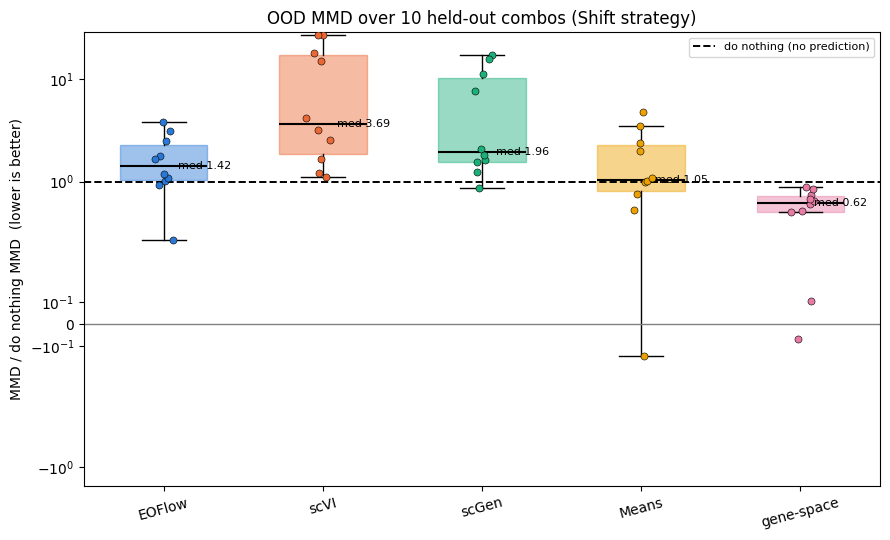

,EOFlow,scVI,scGen,Means,do nothing,gene-space
combo_1,0.0406,0.1275,0.0825,0.0212,0.0398,0.0204
combo_2,0.0121,0.0866,0.0549,0.0063,0.0032,0.0003
combo_3,0.0322,0.1224,0.0455,0.1025,0.0293,0.0177
combo_4,0.0418,0.0581,0.0578,0.0345,0.0351,0.0313
combo_5,0.0095,0.0976,0.0853,0.0258,0.0054,0.0028
combo_6,0.0101,0.1125,0.0459,-0.0006,0.0041,-0.0003
combo_7,0.0412,0.1309,0.1341,0.0807,0.1073,0.0801
combo_8,0.0162,0.0798,0.0406,0.0124,0.0052,0.0033
combo_9,0.4471,0.5366,0.4112,0.4841,0.4788,0.4085
combo_10,0.0664,0.1017,0.0737,0.0435,0.0400,0.0271


In [15]:
from src.analysis.mmd import comparable_ood_mmd, plot_mmd_boxplot

# one "predict this combo" callable per model, wrapping each model's own path
def _eoflow_predict(combo):
    return inn_sample_leftout_combo_shift(
        model=eoflow_analyzer.model, adata=eoflow_analyzer.adata,
        combo_categories=eoflow_combo_categories, conditions=eoflow_combo_conditions,
        holdout_combo=combo, condition_key=eoflow_labels_key,
        control_label=eoflow_control_label, cell_type_key="cell_type",
        observed_combos=eoflow_observed_combos,
    )

def _scvi_predict(combo):
    return inn_sample_leftout_combo_shift(
        model=scvi_analyzer.model, adata=scvi_analyzer.adata,
        combo_categories=scvi_combo_categories, conditions=combo_conditions,
        holdout_combo=combo, condition_key=scvi_labels_key,
        control_label=scvi_control_label, cell_type_key="cell_type",
        observed_combos=scvi_observed_combos,
    )

def _scgen_predict(combo):
    predicted, _ = scgen_analyzer.model.predict(
        ctrl_key=scgen_control_label, stim_key=combo[scgen_labels_key],
        celltype_to_predict=combo["cell_type"],
    )
    predicted.obs[scgen_labels_key] = combo[scgen_labels_key]
    return predicted

def _mean_predict(combo):
    return mean_sample_leftout_combo_shift(
        mean_shifter, mean_analyzer.adata, holdout_combo=combo,
        condition_key=mean_labels_key, control_label=mean_control_label,
        cell_type_key="cell_type",
    )

PREDICTORS = {"EOFlow": _eoflow_predict, "scVI": _scvi_predict,
              "scGen": _scgen_predict, "Means": _mean_predict}

# real cells and the gene-space baseline come from one analyzer (EOFlow's); canonicalization
# inside comparable_ood_mmd puts every model's prediction on that same footing
_ref = eoflow_analyzer.adata
_obs_cyt = _ref.obs[eoflow_labels_key].astype(str)
_obs_cell = _ref.obs["cell_type"].astype(str)

def _gene_space_shift(combo):
    """The same additive assumption applied in expression space, per combo."""
    cyt, cell = combo[eoflow_labels_key], combo["cell_type"]
    X = _ref.X.toarray() if hasattr(_ref.X, "toarray") else np.asarray(_ref.X)
    ctrl = X[(_obs_cyt == eoflow_control_label).to_numpy() & (_obs_cell == cell).to_numpy()]
    deltas = []
    for other in sorted(_obs_cell.unique()):
        if other == cell:
            continue
        a = X[(_obs_cyt == cyt).to_numpy() & (_obs_cell == other).to_numpy()]
        b = X[(_obs_cyt == eoflow_control_label).to_numpy() & (_obs_cell == other).to_numpy()]
        if len(a) >= 3 and len(b) >= 3:
            deltas.append(a.mean(0) - b.mean(0))
    return np.clip(ctrl + np.mean(deltas, axis=0), 0, None) if deltas else None

ood_mmd_per_combo, ood_mmd_floors, ood_predictions_per_combo = {}, {}, {}
for name, combo in HOLDOUT_COMBOS.items():
    cyt, cell = combo[eoflow_labels_key], combo["cell_type"]
    real = _ref[(_obs_cyt == cyt).to_numpy() & (_obs_cell == cell).to_numpy()]
    ctrl = _ref[(_obs_cyt == eoflow_control_label).to_numpy() & (_obs_cell == cell).to_numpy()]
    if real.n_obs < 4 or ctrl.n_obs < 4:
        print(f"  {name}: only {real.n_obs} real / {ctrl.n_obs} control cells, skipped")
        continue

    preds = {model: fn(combo) for model, fn in PREDICTORS.items()}
    preds["do nothing"] = ctrl
    gene_space = _gene_space_shift(combo)
    if gene_space is not None:
        preds["gene-space"] = gene_space

    scores, floor, _ = comparable_ood_mmd(real, preds, unbiased=True)
    ood_mmd_per_combo[name] = scores
    ood_mmd_floors[name] = floor
    ood_predictions_per_combo[name] = preds
    print(f"  {name:<9} {cyt} x {cell:<16} n={real.n_obs:>4}  "
          + "  ".join(f"{k} {v:.4f}" for k, v in scores.items()))

print(f"\nnoise floors: median {np.median(list(ood_mmd_floors.values())):+.5f} "
      f"(a perfect prediction scores this)")

# symlog, not linear: normalization puts every combo on one axis, but the *models* still
# span orders of magnitude - scVI has run ~10x do-nothing while EOFlow sits near 0.05, and
# on a linear axis EOFlow and its at-the-floor negatives collapse onto the zero line.
# symlog is linear within a data-derived band around zero (where the good models and the
# negative floor values live) and logarithmic beyond it. Plain log is impossible: the
# unbiased estimator is centred on zero under the null and goes negative at the floor.
fig, ax = plt.subplots(figsize=(9, 5.5))
_, ood_mmd_normalized = plot_mmd_boxplot(
    ood_mmd_per_combo, normalize="do nothing", ax=ax, yscale="symlog",
    title=f"OOD MMD over {len(ood_mmd_per_combo)} held-out combos (Shift strategy)",
)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_mmd_boxplot.png"), dpi=300)
plt.show()

ood_mmd_table = pd.DataFrame(ood_mmd_per_combo).T
ood_mmd_table.to_csv(os.path.join(comparison_dir, "ood_mmd_per_combo.csv"))
ood_mmd_table.round(4)

### 4.4 Which model is best?

The boxes above, reduced to one row per model. With ten combos the interesting question is
no longer "what is the number" but **how often** a model wins, so the table counts combos
rather than only averaging them.

* `median MMD/do-nothing` and its IQR - the box's centre and spread. Below 1 means better
  than not predicting; 0 means indistinguishable from real.
* `beats gene-space` - combos where the model beat the model-free additive baseline. This
  is the column that decides whether the machinery earns its place, and counting combos is
  more honest than comparing means: the per-combo MMDs are on different scales, so a single
  large combo can carry an average while the model loses on most of them.
* `beats do-nothing` - combos where the prediction was better than returning the controls
  untouched. A model failing this on any combo is actively harmful there.
* `at/below noise floor` - combos where the prediction was statistically indistinguishable
  from real data, i.e. at or under the split-half MMD of the real cells themselves. This is
  the only column that means "solved", and it is sample-size dependent: the smaller combos
  have a wider floor and are easier to reach.

`wins` counts combos where that model had the lowest MMD of all four - a model can lead on
median while rarely being the best on any individual combo.

In [16]:
MODEL_NAMES = list(PREDICTORS)          # the four models; the rest are baselines
BASELINES = ["gene-space", "do nothing"]

def _summarize(name):
    raw, norm, beats_gs, beats_dn, at_floor, n = [], [], 0, 0, 0, 0
    for combo, scores in ood_mmd_per_combo.items():
        if name not in scores:
            continue
        value, dn = scores[name], scores["do nothing"]
        gs = scores.get("gene-space")
        n += 1
        raw.append(value)
        if dn:
            norm.append(value / dn)
        beats_dn += int(value < dn)
        at_floor += int(value <= ood_mmd_floors[combo])
        if gs is not None:
            beats_gs += int(value < gs)
    return {
        "model": name,
        "combos": n,
        "median MMD/do-nothing": float(np.median(norm)) if norm else np.nan,
        "IQR": (f"{np.quantile(norm, 0.25):.2f} to {np.quantile(norm, 0.75):.2f}"
                if len(norm) > 1 else ""),
        "beats gene-space": np.nan if name == "gene-space" else f"{beats_gs}/{n}",
        "beats do-nothing": f"{beats_dn}/{n}",
        "at/below noise floor": f"{at_floor}/{n}",
        "median raw MMD": float(np.median(raw)) if raw else np.nan,
    }

# which model had the lowest MMD on each combo
wins = {name: 0 for name in MODEL_NAMES}
for combo, scores in ood_mmd_per_combo.items():
    ranked = sorted((scores[m], m) for m in MODEL_NAMES if m in scores)
    if ranked:
        wins[ranked[0][1]] += 1

ood_mmd_summary = pd.DataFrame(
    [_summarize(name) for name in MODEL_NAMES + [b for b in BASELINES if b != "do nothing"]]
)
ood_mmd_summary["wins"] = ood_mmd_summary["model"].map(
    lambda m: f"{wins[m]}/{len(ood_mmd_per_combo)}" if m in wins else ""
)
ood_mmd_summary = (
    ood_mmd_summary.sort_values("median MMD/do-nothing").set_index("model").round(4)
)
ood_mmd_summary.to_csv(os.path.join(comparison_dir, "ood_mmd_summary.csv"))

print(f"{len(ood_mmd_per_combo)} held-out combos | median noise floor "
      f"{np.median(list(ood_mmd_floors.values())):+.5f}")
ood_mmd_summary

10 held-out combos | median noise floor -0.00032


,combos,median MMD/do-nothing,IQR,beats gene-space,beats do-nothing,at/below noise floor,median raw MMD,wins
model,,,,,,,,
gene-space,10,0.6239,0.51 to 0.73,NaN,10/10,0/10,0.0191,
Means,10,1.0483,0.81 to 2.29,1/10,4/10,1/10,0.0301,6/10
EOFlow,10,1.4227,1.04 to 2.30,1/10,2/10,0/10,0.0364,3/10
scGen,10,1.9573,1.57 to 10.37,0/10,1/10,0/10,0.0658,1/10
scVI,10,3.6902,1.87 to 17.49,0/10,0/10,0/10,0.1071,0/10


### 4.5 Mean Expression

The 2x2 grid stays on a single combo (`HOLDOUT_COMBO`) - four scatter panels are already a
full figure, and twelve would be unreadable. The R^2 values underneath are the same
quantity computed for **every** held-out combo and aggregated, so the figure shows what the
comparison looks like while the table says whether it holds up.

A warning about what these R^2 values are. They are squared correlations of **absolute mean
expression**, real against predicted, which is dominated by baseline expression level: most
genes barely respond to a perturbation, so any prediction that roughly reproduces the cell
type scores above 0.85, including one that predicts no treatment effect at all. They are
reported here for continuity with the figure, and because a *low* value still means
something is badly wrong - but they cannot rank models. Section 4.6 removes the baseline by
working on effect sizes, and that is the table to compare models on.

Predictions are reused from 4.3, so the same generated cells are behind the figure, the
R^2 table, and every MMD number above.

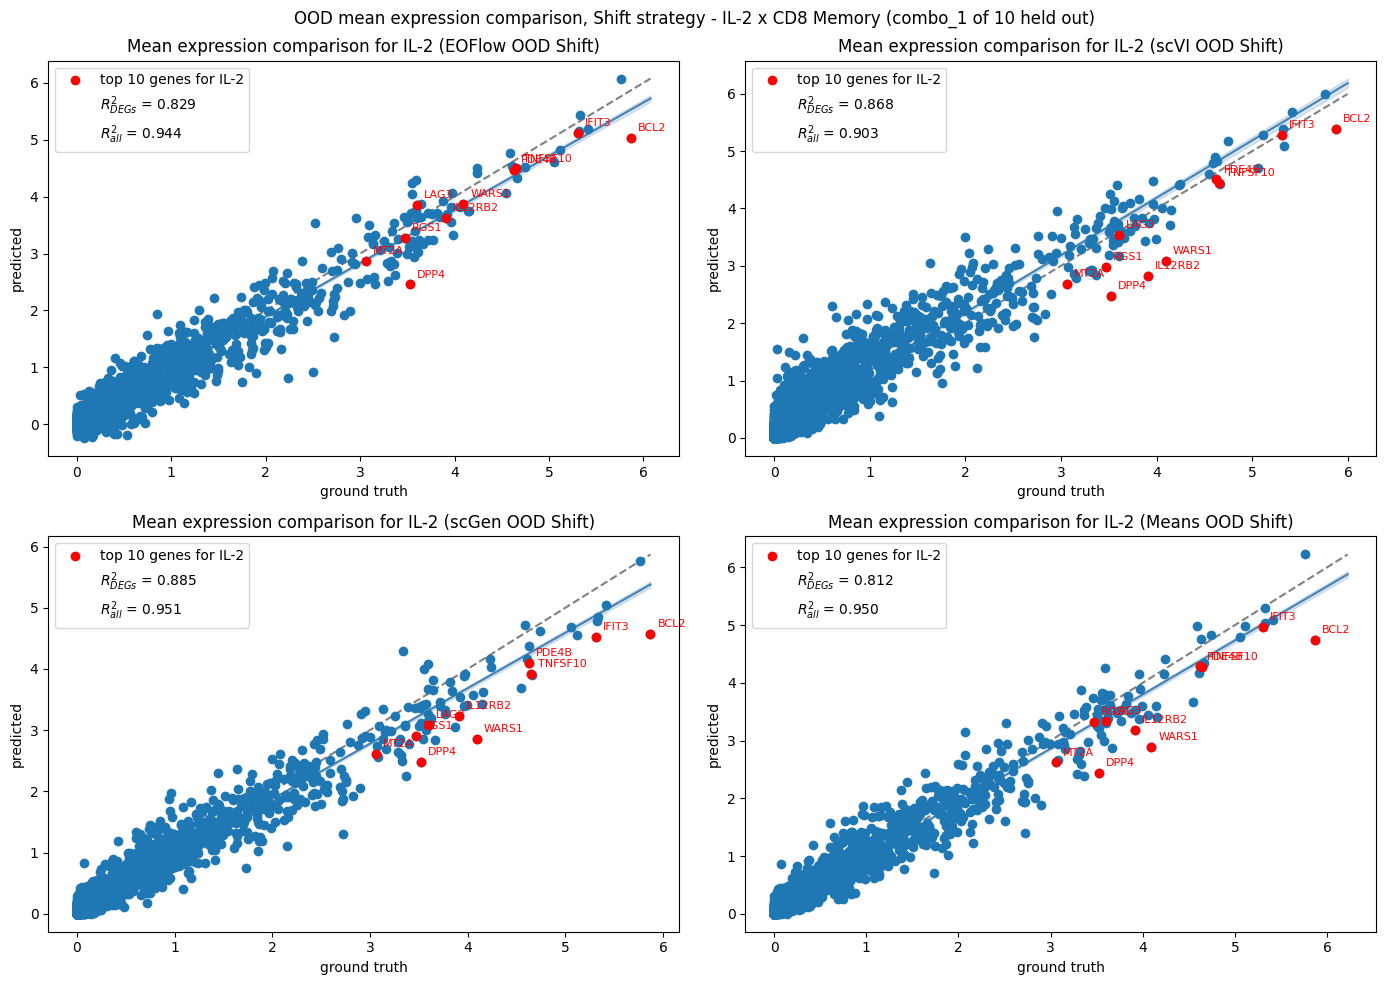

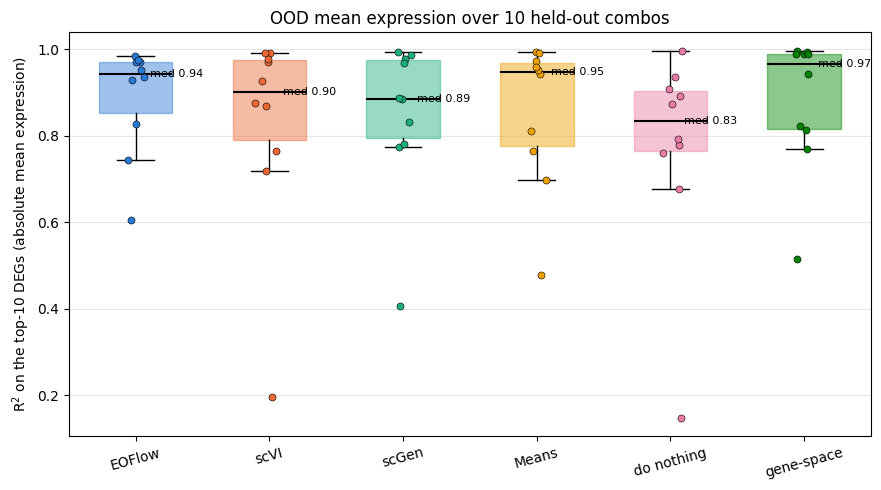

mean-expression R^2 over 10 held-out combos (baseline-dominated - see 4.6 for the informative version)


R2_all               R2_DEGs              
           median    min    max  median    min    max
model                                                
EOFlow      0.977  0.757  0.991   0.944  0.606  0.986
gene-space  0.977  0.764  0.994   0.967  0.516  0.996
scGen       0.973  0.815  0.986   0.886  0.406  0.995
do nothing  0.973  0.713  0.991   0.834  0.148  0.997
Means       0.969  0.699  0.987   0.948  0.477  0.994
scVI        0.953  0.736  0.969   0.901  0.195  0.993

In [17]:
from src.analysis.mmd import canonicalize
from src.analysis.cf_expressions import plot_metric_boxplot
from src.utils.utils import extract_top_genes

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(ood_models, axes.flat):
    cfs_fn = cfs_fn_from_adata(m["predictions"]["Shift"], source_label="Shift")
    plot_mean_expression_comparison(
        m["scoped_analyzer"],
        key=m["key"],
        top_n=10,
        cfs_fn=cfs_fn,
        log1p_transform=m["log1p_transform"],
        method=f"{m['name']} OOD Shift",
        ax=ax,
    )
fig.suptitle(f"OOD mean expression comparison, Shift strategy - {HOLDOUT_CONTEXT}")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_mean_expression_comparison.png"), dpi=300)
plt.show()

# ---- the same R^2, for every held-out combo
_r2 = lambda a, b: float(np.corrcoef(a, b)[0, 1] ** 2)

mean_expr_rows = []
for name, combo in HOLDOUT_COMBOS.items():
    if name not in ood_predictions_per_combo:
        continue
    cyt, cell = combo[eoflow_labels_key], combo["cell_type"]
    real = canonicalize(
        _ref[(_obs_cyt == cyt).to_numpy() & (_obs_cell == cell).to_numpy()]
    ).mean(0)

    # DEGs selected exactly as the figure does, per combo: rank_genes_groups within that
    # cell type via extract_top_genes, so the table's DEG column matches the red points
    scoped = scoped_analyzer_for_combo(
        eoflow_analyzer, combo, eoflow_combo_conditions, eoflow_labels_key,
        cell_type_key="cell_type",
    )
    _, gene_idx = extract_top_genes(scoped, key=cyt, top_n=10)

    for model, pred in ood_predictions_per_combo[name].items():
        predicted = canonicalize(pred).mean(0)
        mean_expr_rows.append({
            "combo": name, "model": model,
            "R2_all": _r2(predicted, real),
            "R2_DEGs": _r2(predicted[gene_idx], real[gene_idx]),
        })

mean_expr_per_combo = pd.DataFrame(mean_expr_rows)

# every model clears 0.8 here and the boxes overlap: that is the baseline domination the
# markdown warns about, shown rather than asserted. The spread is the useful part - a low
# outlier is a combo whose effect is large enough to move even the absolute mean.
fig, ax = plt.subplots(figsize=(9, 5))
plot_metric_boxplot(
    mean_expr_per_combo, "R2_DEGs", ax=ax,
    ylabel="R$^2$ on the top-10 DEGs (absolute mean expression)",
    title=f"OOD mean expression over {len(set(m['combo'] for m in mean_expr_rows))} "
          f"held-out combos",
)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_mean_expression_r2_degs_boxplot.png"), dpi=300)
plt.show()

mean_expr_summary = (
    mean_expr_per_combo.groupby("model")[["R2_all", "R2_DEGs"]]
    .agg(["median", "min", "max"])
    .round(3)
    .sort_values(("R2_all", "median"), ascending=False)
)
mean_expr_per_combo.to_csv(os.path.join(comparison_dir, "ood_mean_expression_per_combo.csv"),
                           index=False)
print(f"mean-expression R^2 over {mean_expr_per_combo.combo.nunique()} held-out combos "
      f"(baseline-dominated - see 4.6 for the informative version)")
mean_expr_summary

### 4.6 Effect Size

Same two-level layout as 4.5: the 2x2 grid stays on one combo, the table underneath scores
every held-out combo. The difference is what is being scored. 4.5 compares *absolute* mean
expression, where doing nothing already reaches R^2 = 0.97 because the cell type's own
baseline dominates; here the control mean is subtracted first, so what is left is only the
treatment effect and the null is "no effect at all".

Three numbers per combo, from `effect_size_scores`:

- **`cos2`** - squared uncentered correlation, i.e. the residual R^2 the prediction would
  reach *after* being optimally rescaled. Pure direction: which genes move, and which way.
- **`r2`** - `1 - SS_res/SS_tot` with `SS_tot` about **zero**, not about the mean. `r2 = 0`
  is exactly the do-nothing baseline and negative means worse than predicting no change.
  Unlike a squared Pearson correlation this one sees magnitude errors: perfect direction at
  half the true amplitude scores 0.75.
- **`scale`** - the factor the prediction would need to be multiplied by to minimise the
  residual. `> 1` means the effect is under-predicted. `cos2 - r2` is precisely what
  mis-scaling costs, which separates "wrong direction" from "right direction, wrong size" -
  two failures the squared Pearson of 4.5 reported as one number.

`do nothing` is in the table as the anchor: its effect is identically zero, so it scores
`cos2 = r2 = 0` by construction, and any model below that line is actively harmful.


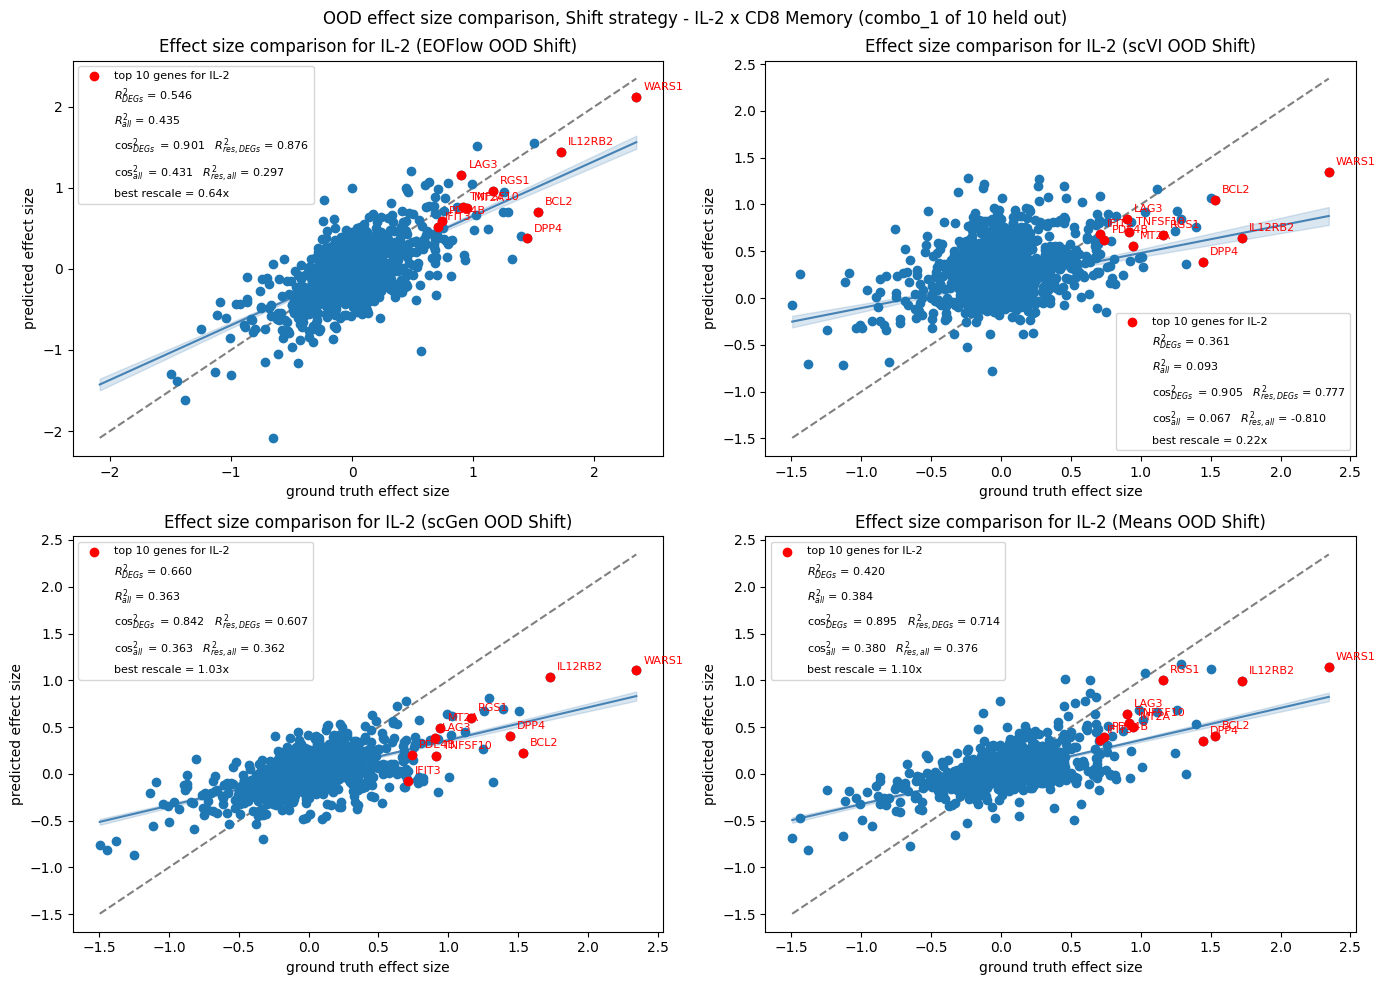

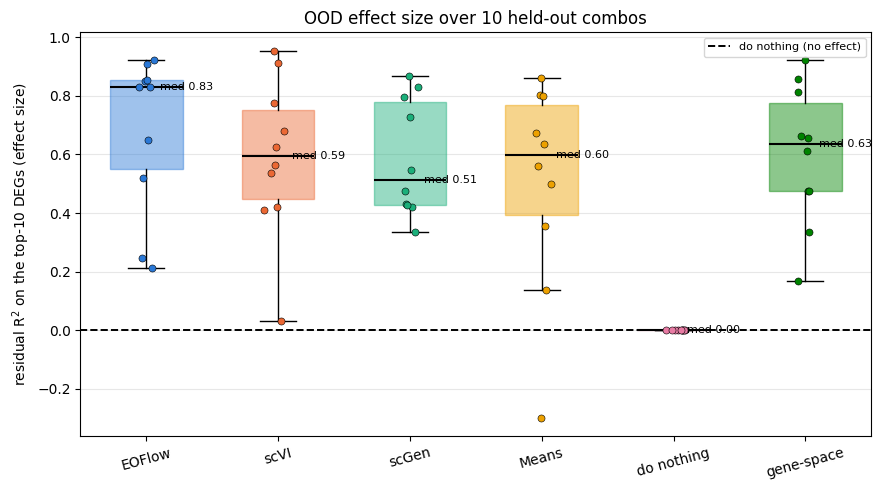

effect-size scores over 10 held-out combos (medians; beats_null counts combos with r2 > 0, i.e. better than doing nothing)


,cos2,r2,scale,cos2_DEGs,r2_DEGs,beats_null
model,,,,,,
gene-space,0.259,0.255,0.868,0.708,0.634,10
do nothing,0.000,0.000,NaN,0.000,0.000,0
Means,0.116,-0.075,0.433,0.617,0.599,3
EOFlow,0.265,-0.095,0.472,0.857,0.830,4
scGen,0.139,-0.144,0.405,0.794,0.512,3
scVI,0.076,-1.593,0.180,0.667,0.594,2


In [18]:
from src.analysis.cf_expressions import effect_size_scores, plot_metric_boxplot

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(ood_models, axes.flat):
    cfs_fn = cfs_fn_from_adata(m["predictions"]["Shift"], source_label="Shift")
    plot_effect_size_comparison(
        m["scoped_analyzer"],
        key=m["key"],
        top_n=10,
        cfs_fn=cfs_fn,
        log1p_transform=m["log1p_transform"],
        method=f"{m['name']} OOD Shift",
        ax=ax,
    )
fig.suptitle(f"OOD effect size comparison, Shift strategy - {HOLDOUT_CONTEXT}")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_effect_size_comparison.png"), dpi=300)
plt.show()

# ---- direction and magnitude of the effect, for every held-out combo
effect_rows = []
for name, combo in HOLDOUT_COMBOS.items():
    if name not in ood_predictions_per_combo:
        continue
    preds = ood_predictions_per_combo[name]
    cyt, cell = combo[eoflow_labels_key], combo["cell_type"]

    # the control mean is subtracted from both sides, so it has to come from the same
    # canonical space; preds["do nothing"] is that combo's control cells (set in 4.3)
    ctrl_mean = canonicalize(preds["do nothing"]).mean(0)
    real = canonicalize(
        _ref[(_obs_cyt == cyt).to_numpy() & (_obs_cell == cell).to_numpy()]
    ).mean(0)
    truth = real - ctrl_mean

    scoped = scoped_analyzer_for_combo(
        eoflow_analyzer, combo, eoflow_combo_conditions, eoflow_labels_key,
        cell_type_key="cell_type",
    )
    _, gene_idx = extract_top_genes(scoped, key=cyt, top_n=10)

    for model, pred in preds.items():
        delta = canonicalize(pred).mean(0) - ctrl_mean
        allg = effect_size_scores(delta, truth)
        degs = effect_size_scores(delta[gene_idx], truth[gene_idx])
        effect_rows.append({
            "combo": name, "model": model,
            "cos2": allg["cos2"], "r2": allg["r2"], "scale": allg["scale"],
            "cos2_DEGs": degs["cos2"], "r2_DEGs": degs["r2"],
        })

effect_per_combo = pd.DataFrame(effect_rows)

# the same ten combos as the plot above, scored on the effect instead of the level: here
# the boxes separate, and the do-nothing box collapses onto the dashed line it defines.
fig, ax = plt.subplots(figsize=(9, 5))
plot_metric_boxplot(
    effect_per_combo, "r2_DEGs", ax=ax, hline=0.0, hline_label="do nothing (no effect)",
    ylabel="residual R$^2$ on the top-10 DEGs (effect size)",
    title=f"OOD effect size over {effect_per_combo.combo.nunique()} held-out combos",
)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_effect_size_r2_degs_boxplot.png"), dpi=300)
plt.show()

effect_summary = (
    effect_per_combo.groupby("model")
    .agg(
        cos2=("cos2", "median"),
        r2=("r2", "median"),
        scale=("scale", "median"),
        cos2_DEGs=("cos2_DEGs", "median"),
        r2_DEGs=("r2_DEGs", "median"),
        # how often the model is worth using at all, rather than how well it does on average
        beats_null=("r2", lambda s: int((s > 0).sum())),
    )
    .round(3)
    .sort_values("r2", ascending=False)
)
effect_per_combo.to_csv(os.path.join(comparison_dir, "ood_effect_size_per_combo.csv"),
                        index=False)
print(f"effect-size scores over {effect_per_combo.combo.nunique()} held-out combos "
      f"(medians; beats_null counts combos with r2 > 0, i.e. better than doing nothing)")
effect_summary


### 4.7 Support and dispersion

MMD says *how far* a prediction is from the real cells; this says *why*. Counterfactuals
have consistently come out under-dispersed and short of the data's zero-inflation, and
both are invisible to a mean-based score - a prediction can have near-perfect mean effect
(cos^2 > 0.95) while carrying half the variance.

Everything is canonicalized to one space first (as in 4.3), because a variance computed on
raw counts and one on log-normalized data differ by orders of magnitude for reasons that
have nothing to do with model quality. The DE gene set is shared across models rather than
selected per model, for the same reason.

`zero frac` uses a tolerance (|x| < 0.1) rather than `== 0`: an exact test reports ~0% even
for a perfect round trip through the flow, which returns zeros as +-2e-5.

The table is `combo_1` in detail; the boxplots underneath are the same two quantities over
all ten held-out combos. `var ratio` is already relative to that combo's real cells, so 1.0
is the target and the dashed line is where a correctly dispersed model sits. `zero frac` is
not normalized - the real zero fraction varies by cell type - so the real cells are carried
along as their own box and the question is which model's box overlaps it.


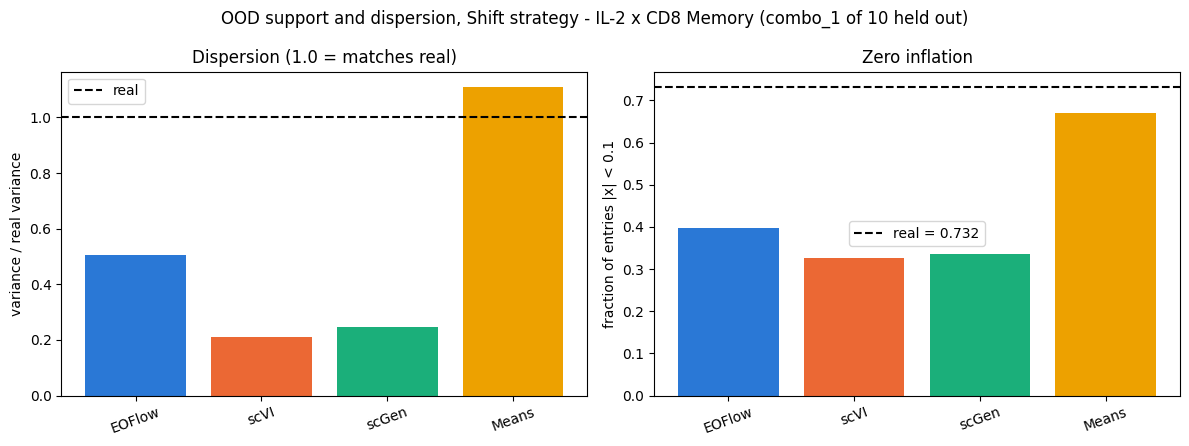

real: total variance 790, zero fraction 0.732


,var ratio,zero frac,cos2,R2_res,best rescale,MMD
model,,,,,,
EOFlow,0.505,0.398,0.826,0.810,1.161,0.041
scVI,0.212,0.326,0.632,0.557,1.530,0.128
scGen,0.247,0.335,0.586,0.547,1.349,0.082
Means,1.109,0.671,0.719,0.569,1.842,0.021


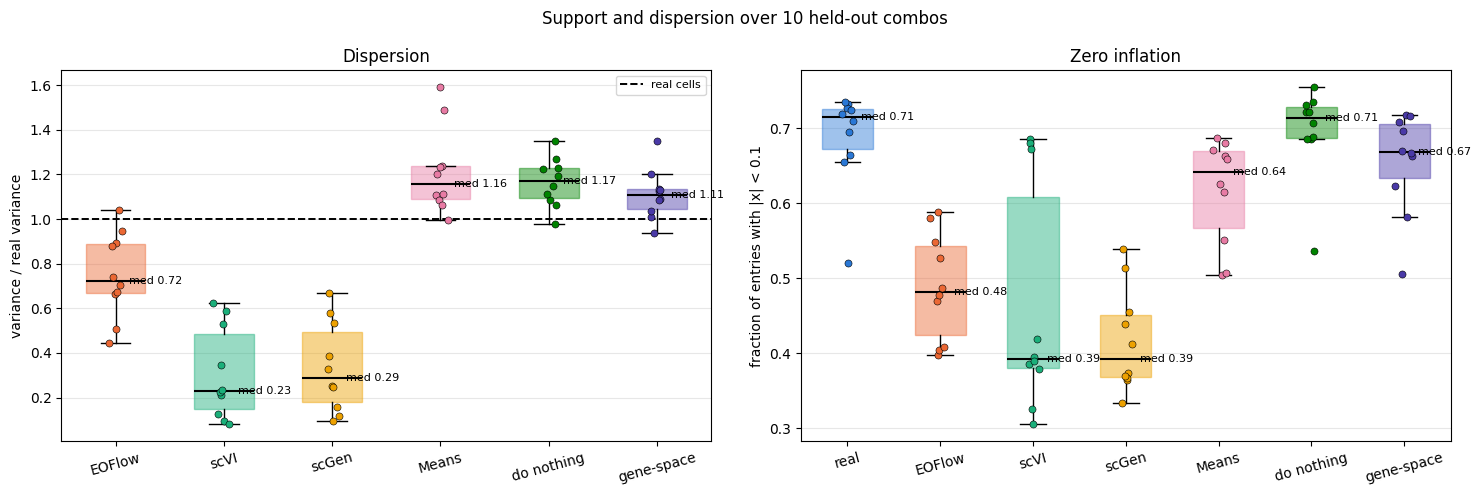

medians over 10 held-out combos


,var ratio,zero frac
model,,
do nothing,1.169,0.714
Means,1.156,0.642
gene-space,1.109,0.668
real,1.000,0.714
EOFlow,0.723,0.482
scGen,0.289,0.393
scVI,0.228,0.392


In [19]:
from src.analysis.cf_expressions import (
    comparable_support_table, plot_support_table, plot_metric_boxplot,
)
from src.analysis.mmd import canonicalize

ref = ood_models[0]
ref_adata = ref["scoped_analyzer"].adata
ref_obs = ref_adata.obs[ref["scoped_analyzer"].labels_key].astype(str)

ood_support_table = comparable_support_table(
    real=ref_adata[ref_obs == ref["key"]],
    control=ref_adata[ref_obs == ref["scoped_analyzer"].control_label],
    predictions={m["name"]: m["predictions"]["Shift"] for m in ood_models},
    # 4.3 scores every combo, so take this combo's column out of that rather than
    # recomputing an MMD here - the two would otherwise drift apart
    extra={name: {"MMD": value}
           for name, value in ood_mmd_per_combo[HOLDOUT_NAME].items()},
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_support_table(ood_support_table, ax=axes)
fig.suptitle(f"OOD support and dispersion, Shift strategy - {HOLDOUT_CONTEXT}")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_support.png"), dpi=300)
plt.show()

print(f"real: total variance {ood_support_table.attrs['real_var']:.0f}, "
      f"zero fraction {ood_support_table.attrs['real_zero_frac']:.3f}")
ood_support_table.to_csv(os.path.join(comparison_dir, "ood_support.csv"))
display(ood_support_table.round(3))

# ---- the same two quantities, for every held-out combo
_zero_frac = lambda x: float((np.abs(x) < 0.1).mean())

support_rows = []
for name, combo in HOLDOUT_COMBOS.items():
    if name not in ood_predictions_per_combo:
        continue
    cyt, cell = combo[eoflow_labels_key], combo["cell_type"]
    real_c = canonicalize(
        _ref[(_obs_cyt == cyt).to_numpy() & (_obs_cell == cell).to_numpy()]
    )
    real_var = float(real_c.var(0).sum())
    support_rows.append({"combo": name, "model": "real",
                         "var ratio": 1.0, "zero frac": _zero_frac(real_c)})
    for model, pred in ood_predictions_per_combo[name].items():
        pred_c = canonicalize(pred)
        support_rows.append({
            "combo": name, "model": model,
            "var ratio": float(pred_c.var(0).sum()) / real_var,
            "zero frac": _zero_frac(pred_c),
        })

support_per_combo = pd.DataFrame(support_rows)
# "real" is the target in the zero-fraction panel but would only restate the dashed line
# in the variance panel, where it is 1.0 by construction
_all_models = list(dict.fromkeys(support_per_combo.model))
_models = [m for m in _all_models if m != "real"]

# color_order on both panels: the left one drops "real", so without it every model would
# shift one colour between the two halves of the same figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_metric_boxplot(
    support_per_combo, "var ratio", ax=axes[0], order=_models, color_order=_all_models,
    hline=1.0, hline_label="real cells", ylabel="variance / real variance",
    title="Dispersion",
)
plot_metric_boxplot(
    support_per_combo, "zero frac", ax=axes[1], color_order=_all_models,
    ylabel="fraction of entries with |x| < 0.1", title="Zero inflation",
)
fig.suptitle(f"Support and dispersion over {support_per_combo.combo.nunique()} "
             f"held-out combos")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_support_boxplot.png"), dpi=300)
plt.show()

support_summary = (
    support_per_combo.groupby("model")[["var ratio", "zero frac"]]
    .median()
    .round(3)
    .sort_values("var ratio", ascending=False)
)
support_per_combo.to_csv(os.path.join(comparison_dir, "ood_support_per_combo.csv"),
                         index=False)
print(f"medians over {support_per_combo.combo.nunique()} held-out combos")
support_summary


### 4.8 Can a classifier tell them apart?

A classifier two-sample test, reusing the origin-classifier setup from
`logistic_regression.evaluate_cf_roc` (label real cells "original" and predictions "cfs",
train, score a held-out split) via its OOD sibling `evaluate_leftout_combo_roc`.

This is a different question from 4.3. MMD compares the two samples through a fixed
Gaussian kernel at a median bandwidth - a smooth, isotropic test that in 1937 dimensions
averages over all directions. A learned discriminator only has to find *one* direction that
separates, so it picks up structured defects the kernel smooths over, and these
counterfactuals have known structural defects (too little variance, too few exact zeros,
see 4.7). The two metrics can and do disagree; that disagreement is informative.

AUC 0.5 = indistinguishable from real. It means nothing without the two references:

* **real vs real** - two halves of the real cells. This is the floor; anything much above
  0.5 means the test is overfitting at this sample size and every bar is inflated with it.
* **real vs control** - what a model scores by returning the control cells unchanged. A
  model has to beat *this* to have done anything useful, not the floor.

Predictions are canonicalized to one space first, as in 4.3, so a count-space model is not
separated from log-space real cells on units alone.

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 204.32it/s]

Best Validation Accuracy: 0.7143


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 787.49it/s]


Best Validation Accuracy: 0.5714


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 778.99it/s]


...

Best Validation Accuracy: 0.9130


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 329.72it/s]


Best Validation Accuracy: 0.8913


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 327.70it/s]


Best Validation Accuracy: 0.8913


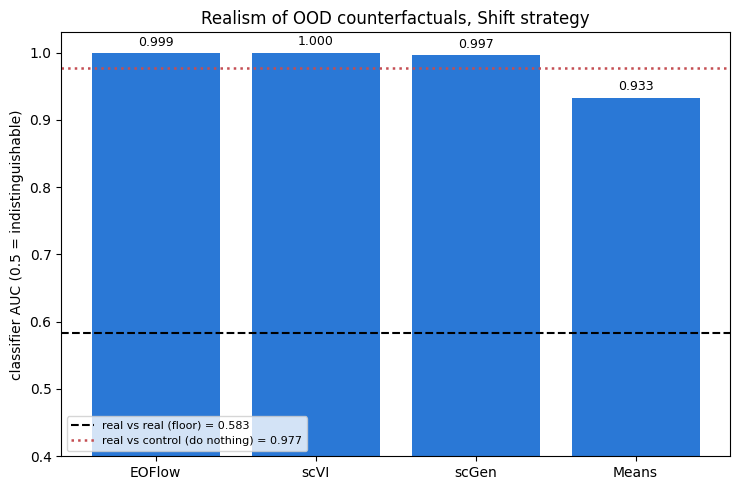

,model,AUC vs real,vs do-nothing
0,Means,0.933114,-0.043860
1,scGen,0.996711,0.019737
2,EOFlow,0.998904,0.021930
3,scVI,1.000000,0.023026


In [20]:
from src.analysis.INN_OOD import evaluate_leftout_combo_roc

ref = ood_models[0]

ood_roc_results, ood_roc_floor, ood_roc_control = evaluate_leftout_combo_roc(
    ref["scoped_analyzer"],
    {m["name"]: m["predictions"]["Shift"] for m in ood_models},
    key=ref["key"],
    num_epochs=10,
    n_repeats=3,      # ~34 real cells means one 20% split scores ~7 of them
)

fig, ax = plt.subplots(figsize=(7.5, 5))
names = list(ood_roc_results)
ax.bar(names, [ood_roc_results[n] for n in names], color="#2a78d6")
ax.axhline(ood_roc_floor, color="black", ls="--", lw=1.5,
           label=f"real vs real (floor) = {ood_roc_floor:.3f}")
if ood_roc_control is not None:
    ax.axhline(ood_roc_control, color="#c44e52", ls=":", lw=1.8,
               label=f"real vs control (do nothing) = {ood_roc_control:.3f}")
for i, n in enumerate(names):
    ax.annotate(f"{ood_roc_results[n]:.3f}", (i, ood_roc_results[n]), ha="center",
                va="bottom", fontsize=9, xytext=(0, 3), textcoords="offset points")
ax.set_ylim(0.4, 1.03)
ax.set_ylabel("classifier AUC (0.5 = indistinguishable)")
ax.set_title("Realism of OOD counterfactuals, Shift strategy")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ood_c2st.png"), dpi=300)
plt.show()

ood_roc_table = pd.DataFrame(
    [{"model": n, "AUC vs real": v, "vs do-nothing": v - ood_roc_control}
     for n, v in ood_roc_results.items()]
).sort_values("AUC vs real").reset_index(drop=True)
ood_roc_table.to_csv(os.path.join(comparison_dir, "ood_c2st.csv"), index=False)
ood_roc_table

### 4.9 The same test on in-distribution counterfactuals

4.8 says a classifier separates the held-out counterfactuals from real cells almost
perfectly. That number only means something against the in-distribution case: if ID
counterfactuals are *equally* separable, the problem is the model's generative realism in
general and has nothing to do with the combo being held out; if they are close to the
floor, then realism is specifically an OOD failure.

Identical procedure to 4.8 - same origin classifier, same repeats, same canonicalization,
same two references - applied to section 3's ID counterfactuals for `key`, produced by each
model's own `cf_fn`.

Not a matched pair, and worth remembering when reading the two side by side: 4.8 predicts
one combo (IL-2 x CD8 Memory) by shifting that cell type's controls, while this transforms
every non-`key` cell across all cell types. It bounds how realistic these models get when
the condition *was* trained; it is not the same prediction task made easier. The strictly
matched version is `eval_checkpoint.py`'s REFERENCE row, which runs the held-out combo's
exact Shift procedure on a trained combo in the same cell type.

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 8 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 62 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 80 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 98 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_c

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 116 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 152 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

Best Validation Accuracy: 0.7872


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  7.97it/s]


Best Validation Accuracy: 0.8315


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  8.01it/s]


Best Validation Accuracy: 0.8247


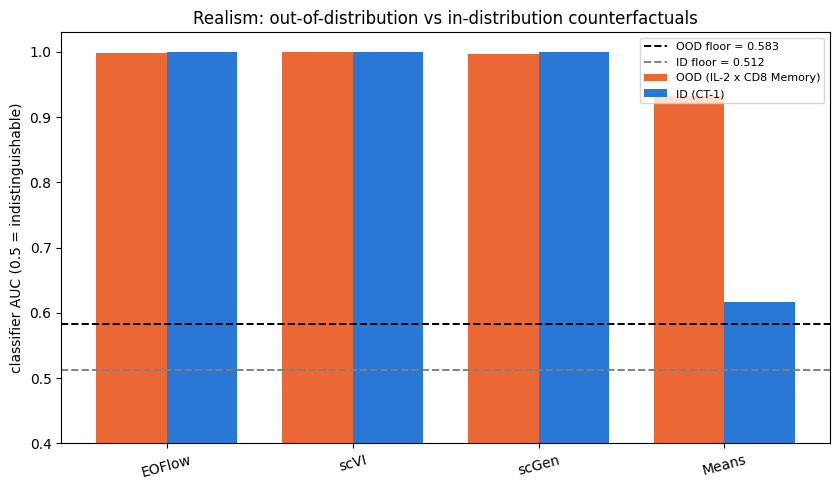

references - OOD: floor 0.583, do-nothing 0.977 | ID: floor 0.512, do-nothing 0.988


,OOD (IL-2 x CD8 Memory),ID (CT-1)
model,,
EOFlow,0.999,1.000
scVI,1.000,1.000
scGen,0.997,0.999
Means,0.933,0.617


In [21]:
id_predictions = {}
for m in models:
    x_cfs, *_ = m["cf_fn"](m["analyzer"], key=key)
    id_predictions[m["name"]] = (
        x_cfs.detach().cpu().numpy() if hasattr(x_cfs, "detach") else np.asarray(x_cfs)
    )

id_roc_results, id_roc_floor, id_roc_control = evaluate_leftout_combo_roc(
    models[0]["analyzer"], id_predictions, key=key, num_epochs=10, n_repeats=3,
)

roc_table = pd.DataFrame(
    [
        {
            "model": name,
            f"OOD ({HOLDOUT_LABEL})": ood_roc_results.get(name, float("nan")),
            f"ID ({key})": id_roc_results[name],
        }
        for name in id_roc_results
    ]
).set_index("model")

fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(roc_table))
width = 0.38
ax.bar(x - width / 2, roc_table.iloc[:, 0], width, label=f"OOD ({HOLDOUT_LABEL})", color="#eb6834")
ax.bar(x + width / 2, roc_table.iloc[:, 1], width, label=f"ID ({key})", color="#2a78d6")
ax.axhline(ood_roc_floor, color="black", ls="--", lw=1.4, label=f"OOD floor = {ood_roc_floor:.3f}")
ax.axhline(id_roc_floor, color="grey", ls="--", lw=1.4, label=f"ID floor = {id_roc_floor:.3f}")
ax.set_xticks(x)
ax.set_xticklabels(roc_table.index, rotation=15)
ax.set_ylim(0.4, 1.03)
ax.set_ylabel("classifier AUC (0.5 = indistinguishable)")
ax.set_title("Realism: out-of-distribution vs in-distribution counterfactuals")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "roc_ood_vs_id.png"), dpi=300)
plt.show()

print(f"references - OOD: floor {ood_roc_floor:.3f}, do-nothing {ood_roc_control:.3f} | "
      f"ID: floor {id_roc_floor:.3f}, do-nothing {id_roc_control:.3f}")
roc_table.to_csv(os.path.join(comparison_dir, "roc_ood_vs_id.csv"))
roc_table.round(3)

### 4.11 Expression histograms - the sanity check behind 4.7-4.10

All gene-expression entries pooled (every cell x gene value, flattened), real against each
model's output. One picture of what the summary metrics each see only a piece of:

* **the atom at zero.** ~73% of real entries are exactly 0; the models put no mass on that
  point, replacing it with a smooth hump about the width of the dequantization noise they
  were trained with. A continuous density cannot place mass on a point, so this is
  structural, not a tuning failure - 4.7's zero fraction, seen directly.
* **the forbidden zone.** Real entries jump from 0 straight to one count (~0.94 in log
  space at median metacell depth), so the interval between is empty by construction. The
  models fill it. This is the count lattice, and it is the most linearly-detectable
  difference in the data - a far easier feature for 4.8's classifier than negativity.
* **the negative tail**, ~32% of raw decoder entries, which real expression never has.
* **the agreement above ~1.0**, where the two track each other over four orders of
  magnitude. That is why MMD and the effect sizes look reasonable: everything separating
  real from generated lives in the low-expression region the inset zooms into.

Two things this cell does deliberately:

**Raw, unclamped predictions.** Every other section scores the clamped output, because that
is what the downstream metrics consume; here the clamp would hide the negative tail by
piling it onto exactly 0. EOFlow, scVI and Means are regenerated with `clamp_min=None`;
scGen's `predict()` never clamped in the first place, so its stored predictions are already
raw - which also means scGen has been evaluated unclamped everywhere else while the others
were clamped.

**Per-panel real cells.** Each model's analyzer holds its own space - scVI's are raw counts,
EOFlow's log-normalized - so a single shared reference would compare a log-space histogram
against a count-space one. Each panel therefore uses its own model's real cells and its own
`log1p_transform` flag; the transform is sign-preserving, so negatives survive it.

[_average_treatment_shift] skipped 3 cell type(s) with no training data for 'IL-2' and/or 'PBS': ['ILC', 'NKT', 'Plasmablast']


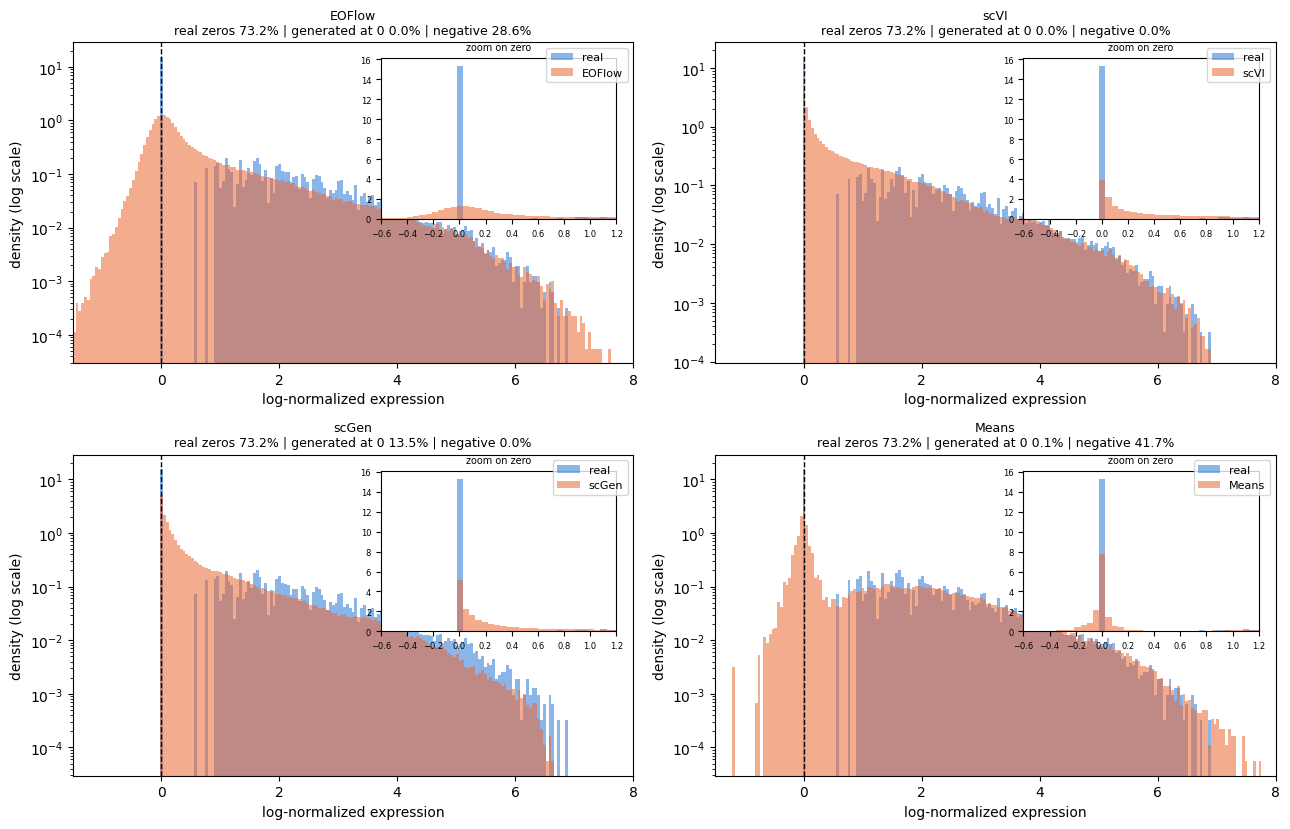

,% entries < 0,% cells with any,min,mean where < 0,negative mass %
model,,,,,
EOFlow,0.2857,1.0,-2.4754,-0.1635,0.0701
scVI,0.0000,0.0,0.0000,0.0000,0.0000
scGen,0.0000,0.0,0.0000,0.0000,0.0000
Means,0.4172,1.0,-1.1729,-0.0599,0.0393


In [22]:
from src.analysis.cf_expressions import plot_expression_histograms, negativity_table

# raw (unclamped) counterparts of the Shift predictions built in 4.1
eoflow_shift_raw = inn_sample_leftout_combo_shift(
    model=eoflow_analyzer.model, adata=eoflow_analyzer.adata,
    combo_categories=eoflow_combo_categories, conditions=eoflow_combo_conditions,
    holdout_combo=eoflow_holdout_combo, condition_key=eoflow_labels_key,
    control_label=eoflow_control_label, cell_type_key="cell_type",
    observed_combos=eoflow_observed_combos, clamp_min=None,
)
scvi_shift_raw = inn_sample_leftout_combo_shift(
    model=scvi_analyzer.model, adata=scvi_analyzer.adata,
    combo_categories=scvi_combo_categories, conditions=combo_conditions,
    holdout_combo=scvi_holdout_combo, condition_key=scvi_labels_key,
    control_label=scvi_control_label, cell_type_key="cell_type",
    observed_combos=scvi_observed_combos, clamp_min=None,
)
mean_shift_raw = mean_sample_leftout_combo_shift(
    mean_shifter, mean_analyzer.adata, holdout_combo=mean_holdout_combo,
    condition_key=mean_labels_key, control_label=mean_control_label,
    cell_type_key="cell_type", clamp_min=None,
)
raw_shift = {
    "EOFlow": eoflow_shift_raw,
    "scVI": scvi_shift_raw,
    "scGen": scgen_adata_shift,   # scgen.SCGEN.predict() does not clamp
    "Means": mean_shift_raw,
}

# each panel gets its own real cells, from its own model's analyzer and space
hist_panels = {}
for m in ood_models:
    scoped = m["scoped_analyzer"]
    real_m = scoped.adata[scoped.adata.obs[scoped.labels_key].astype(str) == m["key"]]
    hist_panels[m["name"]] = (real_m, raw_shift[m["name"]], m["log1p_transform"])

plot_expression_histograms(
    hist_panels, plot_dir=plot_dir, filename="ood_expression_histograms.png",
)

negativity_table(raw_shift).round(4)

### 4.12 Gene-level realism

Real cells against each model's, gene by gene. Unlike 3.5, which picks genes by
`extract_top_genes` for *responding to the perturbation*, these are picked for being the
**worst modelled** among genes that are actually expressed - detected in at least 30% of
real cells. Without that restriction the selection fills with genes that are structurally
silent in real cells and merely leak in the predictions, which is section 4.10's (much
smaller) defect.

Two things to read off:

**No single gene gives the model away.** Per-gene one-dimensional AUC has a median of 0.638
over all 1937 genes, and 0.560 over the 778 expressed ones - only 15 genes exceed 0.9. Yet
the 1937-gene classifier in 4.8 reaches 0.99. Its power comes from summing many
weakly-wrong marginals, not from any gene being badly wrong, which is exactly why every
targeted patch (clamping, snapping the forbidden zone, erasing the silent-gene leak) moved
that AUC so little.

**The systematic error is over-detection.** Across the expressed genes the models turn genes
on in ~79% of cells against ~71% for real, higher in 80% of genes, while keeping the mean
roughly right - so they compensate by lowering the expressed level. In the violins that
shows as a real gene's zero spike plus expressed mode being replaced by one broad unimodal
smear covering both: the model cannot represent "this gene is off in *this* cell", which is
the same limitation as the missing zero atom in 4.11, one level up.

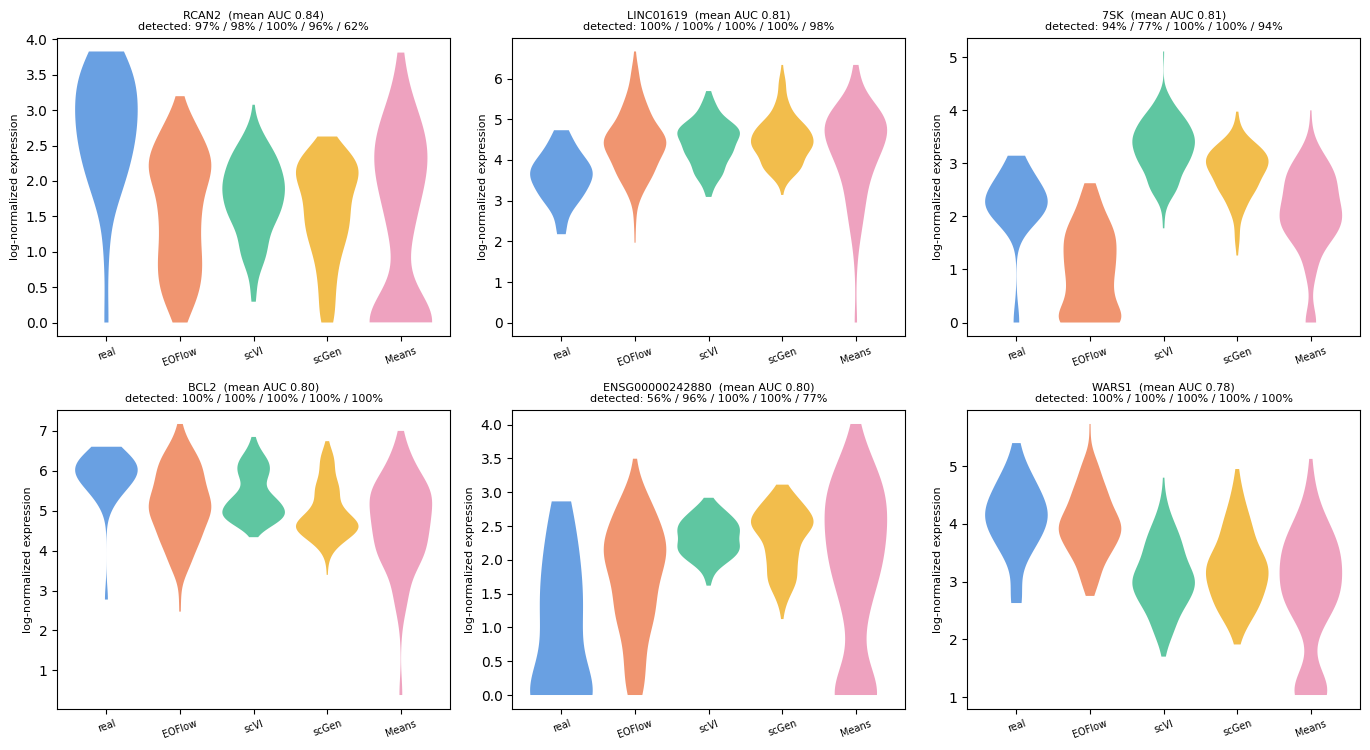

,median AUC (expressed),genes AUC > 0.8,detection real,detection generated,over-detected genes
model,,,,,
EOFlow,0.581,5,0.66,0.909,0.898
scVI,0.626,23,0.66,0.999,0.910
scGen,0.610,13,0.66,0.988,0.908
Means,0.568,6,0.66,0.729,0.544


In [23]:
from src.analysis.cf_expressions import plot_gene_violins, gene_separability

ref = ood_models[0]
ref_adata = ref["scoped_analyzer"].adata
violin_real = ref_adata[ref_adata.obs[ref["scoped_analyzer"].labels_key].astype(str) == ref["key"]]
violin_predictions = {m["name"]: m["predictions"]["Shift"] for m in ood_models}

plot_gene_violins(
    violin_real, violin_predictions, ref_adata.var_names, n_genes=6, min_detection=0.30,
    plot_dir=plot_dir, filename="ood_gene_violins.png",
)

# the summary the panel is a window onto: per-gene separability and the detection gap
gene_stats = {
    name: gene_separability(violin_real, pred, ref_adata.var_names)
    for name, pred in violin_predictions.items()
}
expressed = next(iter(gene_stats.values()))["detect_real"] >= 0.30
gene_summary = pd.DataFrame([
    {
        "model": name,
        "median AUC (expressed)": t.loc[expressed, "auc"].median(),
        "genes AUC > 0.8": int((t.loc[expressed, "auc"] > 0.8).sum()),
        "detection real": t.loc[expressed, "detect_real"].mean(),
        "detection generated": t.loc[expressed, "detect_gen"].mean(),
        "over-detected genes": float((t.loc[expressed, "detect_gen"]
                                      > t.loc[expressed, "detect_real"]).mean()),
    }
    for name, t in gene_stats.items()
]).set_index("model")
gene_summary.to_csv(os.path.join(comparison_dir, "ood_gene_realism.csv"))
gene_summary.round(3)